 # F1 2026 Austrian GP Qualifying Lap Time Prediction and Race Strategy

 ## Introduction

 This notebook analyzes FP1-FP3 data from the 2026 Austrian Grand Prix to understand how practice-session behavior translates into qualifying-style lap pace. The workflow combines data preparation, exploratory analysis, and regression modeling to estimate lap time under controlled assumptions.

  The goal is not just to rank teams by raw pace. It is to identify which combinations of session context, tyre state, driver identity, and speed indicators explain the lap-time variation seen before qualifying.

 ### Event Context

Red Bull Ring rewards strong traction out of the Turn 3 hairpin and the Turn 4, Rauch exit, stability under the circuit's steepest braking zone, Turn 3 decelerates from 331 km/h to 84 km/h over roughly 130 m, pulling 5.3g and straight-line efficiency across a lap where cars run at full throttle for around 79% of the distance. That makes lap time sensitive to rear-tyre thermal degradation from repeated heavy braking and traction demands, power deployment across the circuit's climbing first sector, kerb-riding confidence through Turns 7 and 8, and the compromise between low-drag straight-line setups and the downforce needed for the uphill braking zones.

![Austria Layout](2026trackspielbergdetailed.png)

| Circuit Length (KM) | Number of Turns | Number of Laps | Race Distance (KM) | First Grand Prix | Fastest Lap Time | Driver | Team | Year |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 4.326 | 10 | 71 | 307.018 | 1970 | 1:07.924 (67.924 sec) | Oscar Piastri | McLaren | 2025 |

 ### Research Objectives

 1. Quantify the main factors associated with lap-time variation across the selected all teams.
 2. Examine how pace changes across sessions, stints, tyre compounds, and tyre life.
 3. Benchmark ensemble regression models for qualifying-oriented lap-time prediction.
 4. Translate the best model into a driver-level tyre-life sensitivity view for qualifying scenarios.

 ## Data Preparation

 This section loads the Austrian GP practice data, checks whether local exports already exist, and rebuilds the dataset from FastF1 only when needed. The intent is to keep the notebook reproducible and fast to rerun while preserving a clear path from source data to modeling inputs.

In [1]:
# Importing libraries for data analysis
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.patches import Patch
import seaborn as sns
import fastf1 as ff1
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyRegressor
from itertools import product
from IPython.display import display

# Define event/session metadata once and reuse across notebook
year = 2026
pyear = year - 1
gp = 'Austrian Grand Prix'
cache_gp = 'austrian_gp'
cache_data = f"./f1_{year}_{cache_gp}_cache"
pre_clean_data = f"./f1_{year}_{cache_gp}_pre_clean_data"
plots = f"./f1_{year}_{cache_gp}_plots"
session_names = ['FP1', 'FP2', 'FP3']
qualifying_session_names = ['Q']

# Define pre-cleaned CSV file paths
practice_csv = f'{pre_clean_data}/f1_{year}_{cache_gp}_combined_laps.csv'
qualifying_csv = f'{pre_clean_data}/f1_{year}_{cache_gp}_qualifying_laps.csv'
pyear_qualifying_csv = f'{pre_clean_data}/f1_{pyear}_{cache_gp}_qualifying_laps.csv'

# Define cleaned CSV file paths
practice_csv_cleaned = f'f1_{year}_{cache_gp}_cleaned_laps.csv'
qualifying_csv_cleaned = f'f1_{year}_{cache_gp}_qualifying_cleaned_laps.csv'
pyear_qualifying_csv_cleaned = f'f1_{pyear}_{cache_gp}_qualifying_cleaned_laps.csv'

# Race and pit constants
RACE_LAPS = 71
PIT_STOP_LOSS = 22.0
WARM_UP_LAPS = 3
COMPOUNDS = ['SOFT', 'MEDIUM', 'HARD']

# Keep a stable schema when qualifying is unavailable
qualifying_fallback_columns = ['Session', 'Team', 'Driver', 'DriverNumber', 'LapNumber', 'Stint',
                               'LapTime', 'Compound', 'TyreLife', 'SpeedST', 'TrackStatus'
                               ]

# Prepare cache and event
os.makedirs(cache_data, exist_ok=True)
os.makedirs(pre_clean_data, exist_ok=True)
ff1.Cache.enable_cache(cache_data)
event = ff1.get_event(year, gp)
pyear_event = ff1.get_event(pyear, gp)

# Save figures to dedicated folders
os.makedirs(plots, exist_ok=True)
def save_figure(fig, filename):
    fig.savefig(os.path.join(plots, filename), dpi=150, bbox_inches='tight')

# Extract weather features from session and merge onto laps dataframe
def extract_weather_features(session, laps_df):
    thermal_cols = ['TrackTemp', 'AirTemp', 'Humidity']

    try:
        weather = session.weather_data.copy()
        if weather is None or weather.empty:
            for col in thermal_cols:
                laps_df[col] = np.nan
            return laps_df

        # Normalise weather index to a plain Time column (timedelta from session start)
        if 'Time' not in weather.columns:
            weather = weather.reset_index().rename(columns={'index': 'Time'})

        weather = weather[['Time'] + [c for c in thermal_cols if c in weather.columns]].copy()
        weather['Time'] = pd.to_timedelta(weather['Time'], errors='coerce')
        weather = weather.dropna(subset=['Time']).sort_values('Time').reset_index(drop=True)

        # Use LapStartTime as the join key; fall back to silence if missing
        if 'LapStartTime' not in laps_df.columns:
            for col in thermal_cols:
                laps_df[col] = np.nan
            return laps_df

        laps_df = laps_df.copy()
        laps_df['_LapStartTimeDelta'] = pd.to_timedelta(laps_df['LapStartTime'], errors='coerce')

        merged = pd.merge_asof(
            laps_df.sort_values('_LapStartTimeDelta'),
            weather,
            left_on='_LapStartTimeDelta',
            right_on='Time',
            direction='nearest'
        )

        # Re-align index so assignment back to the original order is safe
        merged = merged.sort_index()
        for col in thermal_cols:
            if col in merged.columns:
                laps_df[col] = merged[col].values
            else:
                laps_df[col] = np.nan

        laps_df = laps_df.drop(columns=['_LapStartTimeDelta'], errors='ignore')
        print(f"  Weather join: TrackTemp range "
              f"{laps_df['TrackTemp'].min():.1f}–{laps_df['TrackTemp'].max():.1f} °C "
              f"across {laps_df['TrackTemp'].notna().sum()} laps.")

    except Exception as exc:
        print(f"  Warning: weather feature extraction failed ({exc}). Columns set to NaN.")
        for col in thermal_cols:
            laps_df[col] = np.nan

    return laps_df

# Shared session cache for downstream telemetry/map analysis
sessions_by_name = {}
session_laps_by_name = {}
qualifying_laps_by_name = {}
pyear_qualifying_laps_by_name = {}

def load_sessions_once(load_telemetry=True):
    for session_name in session_names:
        if session_name in sessions_by_name:
            continue
        try:
            print(f"Loading {session_name}")
            session = event.get_session(session_name)
            session.load(telemetry=load_telemetry, weather=True, messages=False)
            sessions_by_name[session_name] = session

            session_laps = session.laps.copy()
            session_laps['Session'] = session_name
            session_laps = extract_weather_features(session, session_laps)
            session_laps_by_name[session_name] = session_laps
            print(f"Loaded {len(session.laps)} laps from {session_name}")
        except Exception as exc:
            print(f"Warning: {session_name} unavailable or failed to load ({exc}). Skipping this session.")

def load_qualifying_sessions_once(load_telemetry=True):
    for qualifying_session_name in qualifying_session_names:
        if qualifying_session_name in qualifying_laps_by_name:
            continue
        try:
            print(f"Loading {qualifying_session_name}")
            qualifying_session = event.get_session(qualifying_session_name)
            qualifying_session.load(telemetry=load_telemetry, weather=True, messages=False)
            sessions_by_name[qualifying_session_name] = qualifying_session

            qualifying_laps = qualifying_session.laps.copy()
            qualifying_laps['Session'] = qualifying_session_name
            qualifying_laps_by_name[qualifying_session_name] = qualifying_laps
            print(f"Loaded {len(qualifying_laps)} laps from {qualifying_session_name}")
        except Exception as exc:
            print(f"Warning: {qualifying_session_name} unavailable or failed to load ({exc}). Skipping this session.")


def load_pyear_qualifying_sessions_once(load_telemetry=True):
    for qualifying_session_name in qualifying_session_names:
        if qualifying_session_name in pyear_qualifying_laps_by_name:
            continue
        try:
            print(f"Loading previous year {qualifying_session_name}")
            qualifying_session = pyear_event.get_session(qualifying_session_name)
            qualifying_session.load(telemetry=load_telemetry, weather=True, messages=False)

            qualifying_laps = qualifying_session.laps.copy()
            qualifying_laps['Session'] = qualifying_session_name
            pyear_qualifying_laps_by_name[qualifying_session_name] = qualifying_laps
            print(f"Loaded {len(qualifying_laps)} laps from previous year {qualifying_session_name}")
        except Exception as exc:
            print(f"Warning: previous year {qualifying_session_name} unavailable or failed to load ({exc}). Skipping this session.")

# Always initialize these so downstream cells are deterministic
practice_data = None
qualifying_data = None
pyear_qualifying_data = None

# Check if CSV file already exists
if os.path.exists(practice_csv):
    print(f"Loading data from existing CSV file: {practice_csv}")
    practice_data = pd.read_csv(practice_csv)
    print(f"Total laps in practice dataset: {len(practice_data)}")

    print("Re-running weather feature extraction on cached practice data...")
    load_sessions_once(load_telemetry=False)   # telemetry=False keeps this fast
    for session_name in session_names:
        session = sessions_by_name.get(session_name)
        if session is None:
            continue
        mask = practice_data['Session'] == session_name
        if not mask.any():
            continue
        subset = practice_data.loc[mask].copy()
        # Restore LapStartTime temporarily from the raw session laps for the join key
        raw_laps = session.laps.copy()
        raw_laps['Session'] = session_name
        if 'LapStartTime' in raw_laps.columns and 'LapStartTime' not in subset.columns:
            # Match on Driver + LapNumber to bring LapStartTime back in
            key_cols = ['Driver', 'LapNumber']
            subset = subset.merge(
                raw_laps[key_cols + ['LapStartTime']].drop_duplicates(subset=key_cols),
                on=key_cols, how='left'
            )
        enriched = extract_weather_features(session, subset)
        for col in ['TrackTemp', 'AirTemp', 'Humidity']:
            if col in enriched.columns:
                practice_data.loc[mask, col] = enriched[col].values
    print("Weather re-attachment complete.")

    if os.path.exists(qualifying_csv):
        print(f"Loading qualifying data from existing CSV file: {qualifying_csv}")
        qualifying_data = pd.read_csv(qualifying_csv)
    else:
        print("Qualifying CSV not found. Pulling qualifying sessions from FastF1 cache/API.")
        load_qualifying_sessions_once(load_telemetry=True)
        all_qualifying_laps = [qualifying_laps_by_name[s] for s in qualifying_session_names if s in qualifying_laps_by_name]
        if len(all_qualifying_laps) > 0:
            qualifying_data = pd.concat(all_qualifying_laps, ignore_index=True)
            qualifying_data.to_csv(qualifying_csv, index=False)
        else:
            print("Warning: No qualifying sessions available; using empty fallback qualifying dataset.")
            qualifying_data = pd.DataFrame(columns=qualifying_fallback_columns)

    if os.path.exists(pyear_qualifying_csv):
        print(f"Loading previous year qualifying data from existing CSV file: {pyear_qualifying_csv}")
        pyear_qualifying_data = pd.read_csv(pyear_qualifying_csv)
    else:
        print("Previous year qualifying CSV not found. Pulling previous year qualifying session from FastF1 cache/API.")
        load_pyear_qualifying_sessions_once(load_telemetry=True)
        all_pyear_qualifying_laps = [pyear_qualifying_laps_by_name[s] for s in qualifying_session_names if s in pyear_qualifying_laps_by_name]
        if len(all_pyear_qualifying_laps) > 0:
            pyear_qualifying_data = pd.concat(all_pyear_qualifying_laps, ignore_index=True)
        else:
            print("Warning: No previous year qualifying sessions available; using empty fallback qualifying dataset.")
            pyear_qualifying_data = pd.DataFrame(columns=qualifying_fallback_columns)

    # Load sessions once here so telemetry/race-map cells can reuse them
    print("Preparing session cache for telemetry and race map")
    load_sessions_once(load_telemetry=True)
    load_pyear_qualifying_sessions_once(load_telemetry=True)
    load_qualifying_sessions_once(load_telemetry=True)
else:
    print("CSV file not found. Pulling data from FastF1")

    # Load multiple sessions once and combine them
    load_sessions_once(load_telemetry=True)
    all_laps = [session_laps_by_name[s] for s in session_names if s in session_laps_by_name]
    load_qualifying_sessions_once(load_telemetry=True)
    all_qualifying_laps = [qualifying_laps_by_name[s] for s in qualifying_session_names if s in qualifying_laps_by_name]
    load_pyear_qualifying_sessions_once(load_telemetry=True)
    all_pyear_qualifying_laps = [pyear_qualifying_laps_by_name[s] for s in qualifying_session_names if s in pyear_qualifying_laps_by_name]

    if len(all_laps) == 0:
        raise RuntimeError(
            f"No practice sessions in {session_names} could be loaded. "
            "Please check FastF1 cache/network availability or provide the combined CSV file."
        )
    practice_data = pd.concat(all_laps, ignore_index=True)

    if len(all_qualifying_laps) == 0:
        raise RuntimeError(
            f"No qualifying sessions in {qualifying_session_names} could be loaded. "
            "Please check FastF1 cache/network availability or provide the qualifying CSV file."
        )
    qualifying_data = pd.concat(all_qualifying_laps, ignore_index=True)

    if len(all_pyear_qualifying_laps) == 0:
        print("Warning: No previous year qualifying sessions available; using empty fallback qualifying dataset.")
        pyear_qualifying_data = pd.DataFrame(columns=qualifying_fallback_columns)
    else:
        pyear_qualifying_data = pd.concat(all_pyear_qualifying_laps, ignore_index=True)

    # Save the combined dataframe to a CSV file
    practice_data.to_csv(practice_csv, index=False)
    pyear_qualifying_data.to_csv(pyear_qualifying_csv, index=False)
    qualifying_data.to_csv(qualifying_csv, index=False)

print(f"\nPractice Data saved to {practice_csv}")
print(f"Total laps in practice dataset: {len(practice_data)}")

print(f"\nPrevious Year Qualifying Data saved to {pyear_qualifying_csv}")
print(f"Total laps in previous year qualifying dataset: {len(pyear_qualifying_data)}")

print(f"\nQualifying Data saved to {qualifying_csv}")
print(f"Total laps in qualifying dataset: {len(qualifying_data)}")

core           INFO 	Loading data for Austrian Grand Prix - Practice 1 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Loading data from existing CSV file: ./f1_2026_austrian_gp_pre_clean_data/f1_2026_austrian_gp_combined_laps.csv
Total laps in practice dataset: 1595
Re-running weather feature extraction on cached practice data...
Loading FP1


core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['1', '3', '6', '10', '11', '12', '14', '23', '27', '34', '38', '41', '43', '44', '46', '50', '63', '77', '81', '87', '90', '97']
core           INFO 	Loading data for Austrian Grand Prix - Practice 2 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	Using cached data for 

  Weather join: TrackTemp range 48.7–51.4 °C across 500 laps.
Loaded 500 laps from FP1
Loading FP2


req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['1', '3', '5', '6', '10', '11', '12', '14', '16', '18', '23', '27', '30', '31', '41', '43', '44', '55', '63', '77', '81', '87']
core           INFO 	Loading data for Austrian Grand Prix - Practice 3 [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


...

  Weather join: TrackTemp range 49.4–53.0 °C across 464 laps.
Loaded 464 laps from FP3
  Weather join: TrackTemp range 48.7–51.4 °C across 500 laps.
  Weather join: TrackTemp range nan–nan °C across 0 laps.
  Weather join: TrackTemp range nan–nan °C across 0 laps.
Weather re-attachment complete.
Loading qualifying data from existing CSV file: ./f1_2026_austrian_gp_pre_clean_data/f1_2026_austrian_gp_qualifying_laps.csv
Loading previous year qualifying data from existing CSV file: ./f1_2026_austrian_gp_pre_clean_data/f1_2025_austrian_gp_qualifying_laps.csv
Preparing session cache for telemetry and race map
Loading previous year Q


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '16'
core        WARNING 	Fixed incorrect tyre stint information for driver '1'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Fixed incorrect tyre stint information for driver '12'
core        WARNING 	Fixed incorrect tyre stint information for driver '10'
core        WARNING 	Fixed incorrect tyre stint information for driver '14'
core        WARNING 	Fixed incorrect tyre stint information for driver '23'
core        WARNING 	Fixed incorrect tyre stint information for driver '6'
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for posit

Loaded 310 laps from previous year Q
Loading Q


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
core           INFO 	Finished loading data for 22 drivers: ['63', '16', '44', '12', '3', '1', '81', '6', '30', '41', '10', '5', '87', '27', '31', '43', '55', '23', '11', '77', '14', '18']


Loaded 289 laps from Q

Practice Data saved to ./f1_2026_austrian_gp_pre_clean_data/f1_2026_austrian_gp_combined_laps.csv
Total laps in practice dataset: 1595

Previous Year Qualifying Data saved to ./f1_2026_austrian_gp_pre_clean_data/f1_2025_austrian_gp_qualifying_laps.csv
Total laps in previous year qualifying dataset: 310

Qualifying Data saved to ./f1_2026_austrian_gp_pre_clean_data/f1_2026_austrian_gp_qualifying_laps.csv
Total laps in qualifying dataset: 289


 ### Data Preprocessing

 This preprocessing step standardizes lap-level records before analysis.
 
 1. Convert timing fields to numeric seconds.
 2. Remove deleted or inaccurate laps that would distort pace comparisons.
 3. Drop columns that are not required for this notebook's analysis path.
 4. Export the cleaned dataset so the processed source can be reused consistently.

In [2]:
# Cleaning the data
def data_cleaning(data, output_csv_path):
    cleaned_data = data.copy()

    # Convert all time columns to seconds
    time_columns = ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']
    for col in time_columns:
        if col in cleaned_data.columns:
            # If already numeric (seconds), keep as-is
            if pd.api.types.is_numeric_dtype(cleaned_data[col]):
                cleaned_data[col] = pd.to_numeric(cleaned_data[col], errors='coerce')
            else:
                # Handle strings/timedelta-like values
                cleaned_data[col] = pd.to_timedelta(cleaned_data[col], errors='coerce').dt.total_seconds()

    # Remove deleted laps (commonly deleted for track limits)
    if 'Deleted' in cleaned_data.columns:
        deleted_mask = cleaned_data['Deleted'].astype(str).str.lower().isin(['true', '1', 'yes'])
        removed_count = int(deleted_mask.sum())
        cleaned_data = cleaned_data.loc[~deleted_mask].copy()
        print(f"Removed {removed_count} deleted laps.")

    # Remove inaccurate laps (e.g., those with missing or zero lap times)
    if 'IsAccurate' in cleaned_data.columns:
        accurate_mask = cleaned_data['IsAccurate'].astype(str).str.lower().isin(['false', '0', 'no'])
        accurate_count = int(accurate_mask.sum())
        cleaned_data = cleaned_data.loc[~accurate_mask].copy()
        print(f"Removed {accurate_count} inaccurate laps.")

    # Remove DRS from 2025 telmetry
    if 'DRS' in cleaned_data.columns:
        cleaned_data = cleaned_data.drop(columns=['DRS'])

    # Map 2025 data to the 2026 grid and team naming
    if 'Driver' in cleaned_data.columns:
        driver_mask = cleaned_data['Driver'].astype(str).str.upper().isin(['TSU', 'DOO'])
        removed_driver_count = int(driver_mask.sum())
        if removed_driver_count > 0:
            cleaned_data = cleaned_data.loc[~driver_mask].copy()
            print(f"Removed {removed_driver_count} laps from drivers no longer on the grid (e.g., Tsunoda, Doohan).")

    if 'Team' in cleaned_data.columns:
        cleaned_data['Team'] = cleaned_data['Team'].replace({
            'Kick Sauber': 'Audi',
            'Stake F1 Team Kick Sauber': 'Audi'
        })
        print("Mapped 2025 team names to 2026 equivalents (e.g., Kick Sauber -> Audi).")

    # Remove reserve driver laps
    if 'Driver' in cleaned_data.columns:
        driver_mask = cleaned_data['Driver'].astype(str).str.upper().isin(['CRA', 'ARO', 'BEG', 'HIR', 'IWA', 'BRO'])
        removed_driver_count = int(driver_mask.sum())
        if removed_driver_count > 0:
            cleaned_data = cleaned_data.loc[~driver_mask].copy()
            print(f"Removed {removed_driver_count} laps from reserve drivers (e.g., Crawford, Aron).")

    # Drop unnecessary columns (if any)
    columns_to_drop = ['Time', 'PitOutTime', 'PitInTime', 'PitDuration', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
                       'LapStartDateTime', 'LapStartDate', 'LapEndDateTime','Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']
    cleaned_data = cleaned_data.drop(columns=[col for col in columns_to_drop if col in cleaned_data.columns])

    # Save the cleaned dataframe to a CSV file
    cleaned_data.to_csv(output_csv_path, index=False)
    print(f"Cleaned data saved to {output_csv_path}")
    return cleaned_data

practice_df = data_cleaning(practice_data, practice_csv_cleaned)
pyear_qualifying_df = data_cleaning(pyear_qualifying_data, pyear_qualifying_csv_cleaned)
qualifying_df = data_cleaning(qualifying_data, qualifying_csv_cleaned)

Removed 0 deleted laps.
Removed 669 inaccurate laps.
Mapped 2025 team names to 2026 equivalents (e.g., Kick Sauber -> Audi).
Removed 83 laps from reserve drivers (e.g., Crawford, Aron).
Cleaned data saved to f1_2026_austrian_gp_cleaned_laps.csv
Removed 0 deleted laps.
Removed 209 inaccurate laps.
Removed 2 laps from drivers no longer on the grid (e.g., Tsunoda, Doohan).
Mapped 2025 team names to 2026 equivalents (e.g., Kick Sauber -> Audi).
Cleaned data saved to f1_2025_austrian_gp_qualifying_cleaned_laps.csv
Removed 0 deleted laps.
Removed 197 inaccurate laps.
Mapped 2025 team names to 2026 equivalents (e.g., Kick Sauber -> Audi).
Cleaned data saved to f1_2026_austrian_gp_qualifying_cleaned_laps.csv


 ### Data Inspection

 The inspection cells check that the cleaned dataset is structurally sound before any EDA or modeling begins. They confirm the table size, available columns, lap-time distribution, and the team-driver coverage that the later sections rely on.

In [3]:
# Display all data
print(f"Total rows: {len(practice_df)}")
print(f"Total columns: {len(practice_df.columns)}")
print("\nColumn names:")
print(practice_df.columns.tolist())

# Display the dataframe
practice_df

Total rows: 843
Total columns: 23

Column names:
['Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'TrackStatus', 'Session', 'TrackTemp', 'AirTemp', 'Humidity']


,Driver,DriverNumber,LapTime,LapNumber,Stint,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,...,Compound,TyreLife,FreshTyre,Team,LapStartTime,TrackStatus,Session,TrackTemp,AirTemp,Humidity
1,NOR,1,69.255,2.0,1.0,17.173,30.864,21.218,311.0,219.0,...,MEDIUM,2.0,True,McLaren,0 days 01:00:03.498000,1,FP1,50.0,29.9,30.3
2,NOR,1,115.421,3.0,1.0,31.703,57.272,26.446,164.0,157.0,...,MEDIUM,3.0,True,McLaren,0 days 01:01:12.753000,1,FP1,50.0,29.9,30.3
3,NOR,1,68.873,4.0,1.0,17.146,30.714,21.013,310.0,221.0,...,MEDIUM,4.0,True,McLaren,0 days 01:03:08.174000,1,FP1,50.0,29.9,30.3
6,NOR,1,80.681,7.0,2.0,16.946,31.040,32.695,311.0,158.0,...,SOFT,2.0,True,McLaren,0 days 01:07:44.330000,1,FP1,50.0,29.9,30.3
7,NOR,1,116.798,8.0,2.0,30.004,53.787,33.007,174.0,113.0,...,SOFT,3.0,True,McLaren,0 days 01:09:05.011000,1,FP1,50.0,29.9,30.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1585,BEA,87,69.150,10.0,3.0,17.111,30.979,21.060,311.0,217.0,...,SOFT,10.0,False,Haas F1 Team,0 days 00:54:05.824000,1,FP3,NaN,NaN,NaN
1588,BEA,87,68.529,13.0,4.0,16.886,30.651,20.992,316.0,218.0,...,SOFT,2.0,True,Haas F1 Team,0 days 01:05:41.740000,1,FP3,NaN,NaN,NaN
1591,BEA,87,78.315,16.0,5.0,17.044,31.001,30.270,313.0,219.0,...,SOFT,5.0,False,Haas F1 Team,0 days 01:12:21.212000,1,FP3,NaN,NaN,NaN
1592,BEA,87,113.305,17.0,5.0,38.657,47.347,27.301,122.0,167.0,...,SOFT,6.0,False,Haas F1 Team,0 days 01:13:39.527000,1,FP3,NaN,NaN,NaN


In [4]:
# Display basic info
print(f"Dataset shape after cleaning: {practice_df.shape}")
print(f"\nLapTime statistics:")
print(practice_df['LapTime'].describe())

Dataset shape after cleaning: (843, 23)

LapTime statistics:
count    843.000000
mean      82.541752
std       19.408367
min       67.014000
25%       70.425000
50%       72.520000
75%       93.345000
max      149.861000
Name: LapTime, dtype: float64


In [5]:
# Display available teams and drivers
print("Available Teams:")
print(practice_df['Team'].unique())
print("\nAvailable Drivers:")
print(practice_df[['Driver', 'DriverNumber', 'Team']].drop_duplicates().sort_values('Team').reset_index(drop=True))

Available Teams:
['McLaren' 'Red Bull Racing' 'Alpine' 'Cadillac' 'Mercedes' 'Aston Martin'
 'Williams' 'Audi' 'Racing Bulls' 'Ferrari' 'Haas F1 Team']

Available Drivers:
   Driver  DriverNumber             Team
0     COL            43           Alpine
1     GAS            10           Alpine
2     STR            18     Aston Martin
3     ALO            14     Aston Martin
4     BOR             5             Audi
5     HUL            27             Audi
6     PER            11         Cadillac
7     BOT            77         Cadillac
8     LEC            16          Ferrari
9     HAM            44          Ferrari
10    BEA            87     Haas F1 Team
11    OCO            31     Haas F1 Team
12    PIA            81          McLaren
13    NOR             1          McLaren
14    ANT            12         Mercedes
15    RUS            63         Mercedes
16    LIN            41     Racing Bulls
17    LAW            30     Racing Bulls
18    HAD             6  Red Bull Racing
19    VE

In [6]:
# Set palettes
tyre_palette = {'SOFT': '#FF0000', 'MEDIUM': '#FFD400', 'HARD': '#FFFFFF',
                'INTERMEDIATE': '#4bff00', 'WET': '#0000FF'
                }

team_palette = {'Mercedes': '#00D2BE', 'Red Bull Racing': '#1E5BC6', 'Ferrari': '#DC0000',
                'McLaren': '#FF8700', 'Aston Martin': '#006F62', 'Alpine': '#0090FF',
                'Williams': '#005AFF', 'Racing Bulls': '#6692FF', 'Haas F1 Team': '#B6BABD',
                'Audi': '#7A7A7A', 'Cadillac': '#003B5C'
                }

driver_palette = {'LEC': '#DC0000', 'HAM': '#FFF200', 'NOR': '#FF8700', 'PIA': '#000000',
                  'RUS': '#00D2BE', 'ANT': '#C0C0C0', 'VER': '#1E5BC6', 'HAD': '#4C9BFF',
                  'ALB': '#005AFF', 'SAI': '#3A86FF', 'OCO': '#B30000', 'BEA': '#FF4D4D',
                  'LIN': '#2B3B6E', 'LAW': '#E63946', 'GAS': '#0090FF', 'COL': '#FF69B4',
                  'HUL': '#B6BABD', 'BOR': '#FF0000', 'ALO': '#006F62', 'STR': '#00FF9D',
                  'PER': '#003C71', 'BOT': '#A0A0A0',
                  }

# Display palette tables with visible color swatches
def display_palette_table(title, palette_dict):
    df_palette = pd.DataFrame(
        [(name, hex_color) for name, hex_color in palette_dict.items()],columns=['Name', 'Hex']
)

    styled = df_palette.style.apply(
        lambda row: [
            f"background-color: {row['Hex']}; color: black; font-weight: bold;" if col == 'Hex' else ''for col in row.index
            ],axis=1
        )

    print(title)
    display(styled.hide(axis='index'))
    print()

display_palette_table('Tyre Compound Palette', tyre_palette)
display_palette_table('Team Palette', team_palette)
display_palette_table('Driver Palette', driver_palette)

Tyre Compound Palette


Name,Hex
SOFT,#FF0000
MEDIUM,#FFD400
HARD,#FFFFFF
INTERMEDIATE,#4bff00
WET,#0000FF



Team Palette


Name,Hex
Mercedes,#00D2BE
Red Bull Racing,#1E5BC6
Ferrari,#DC0000
McLaren,#FF8700
Aston Martin,#006F62
Alpine,#0090FF
Williams,#005AFF
Racing Bulls,#6692FF
Haas F1 Team,#B6BABD
Audi,#7A7A7A



Driver Palette


Name,Hex
LEC,#DC0000
HAM,#FFF200
NOR,#FF8700
PIA,#000000
RUS,#00D2BE
ANT,#C0C0C0
VER,#1E5BC6
HAD,#4C9BFF
ALB,#005AFF
SAI,#3A86FF


 ## Exploratory Data Analysis

 The EDA section examines pace distribution, session progression, stint structure, straight-line speed, telemetry shape, tyre effects, and degradation behavior. These checks provide the domain context needed to judge whether the feature set is informative enough for machine learning.

 ### Lap Time Distribution

 Distribution plots show how each team's lap times are spread across the practice weekend. The center of each distribution reflects competitive pace, while the tails capture traffic, out-laps, in-laps, cooldowns, and other non-push contexts.

 Comparing histograms with boxplots is useful here because two teams can share similar medians while differing materially in variability. That difference matters for prediction error and for interpreting how stable each team's practice pace really was.

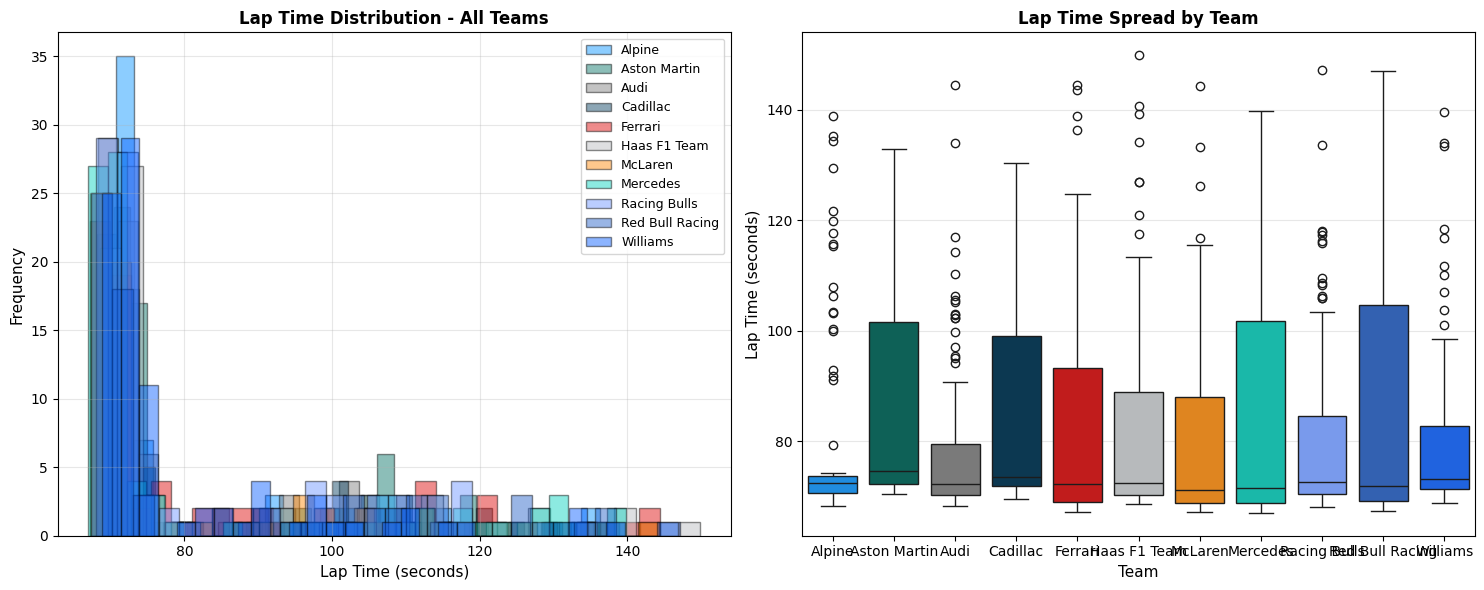

Team Lap Time Summary:
                 count    mean     min     std
Team                                          
Alpine              83  80.350  68.193  18.454
Aston Martin        71  85.430  70.421  17.624
Audi                78  79.664  68.300  16.423
Cadillac            59  83.835  69.521  17.413
Ferrari             77  84.259  67.211  21.355
Haas F1 Team        70  83.237  68.529  21.654
McLaren             68  80.449  67.251  18.703
Mercedes            90  84.300  67.014  22.887
Racing Bulls        84  81.105  68.031  17.970
Red Bull Racing     74  86.467  67.369  23.080
Williams            89  79.826  68.838  15.757


In [7]:
# Team-level lap time distribution for all teams
analysis_df = practice_df.copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram by team
for team in sorted(practice_df['Team'].dropna().unique().tolist()):
    team_laps = analysis_df[analysis_df['Team'] == team]['LapTime'].dropna()
    if not team_laps.empty:
        axes[0].hist(team_laps, bins=28, alpha=0.45, label=team, color=team_palette.get(team, 'gray'), edgecolor='black')

axes[0].set_xlabel('Lap Time (seconds)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Lap Time Distribution - All Teams', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Boxplot by team
box_data = analysis_df.copy()
sns.boxplot(data=box_data,x='Team', y='LapTime', hue='Team', palette=team_palette,
            order=sorted(box_data['Team'].dropna().unique().tolist()),ax=axes[1]
            )

axes[1].set_xlabel('Team', fontsize=11)
axes[1].set_ylabel('Lap Time (seconds)', fontsize=11)
axes[1].set_title('Lap Time Spread by Team', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
save_figure(fig, f"f1_{year}_{cache_gp}_lap_time_distribution.png")

team_summary = (analysis_df.groupby('Team')['LapTime'].agg(['count', 'mean', 'min', 'std'])
                .reindex(sorted(analysis_df['Team'].dropna().unique().tolist())).round(3)
                )

print('Team Lap Time Summary:')
print(team_summary)

 ### Laps Per Driver Distribution

 This view shows how many laps each driver completed across the selected sessions. The compound-sorted breakdown helps separate total run volume from tyre-specific usage patterns before comparing pace or degradation.

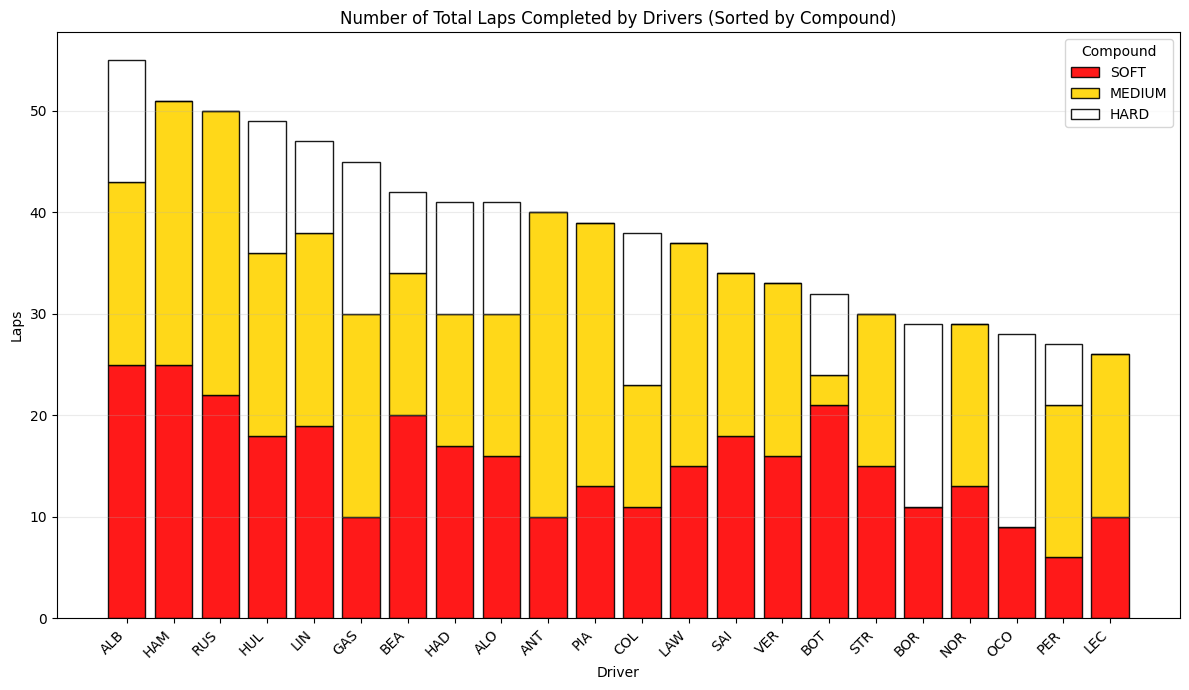

Laps completed by driver and compound (sorted):
Compound  SOFT  MEDIUM  HARD  TotalLaps
Driver                                 
ALB         25      18    12         55
HAM         25      26     0         51
RUS         22      28     0         50
HUL         18      18    13         49
LIN         19      19     9         47
GAS         10      20    15         45
BEA         20      14     8         42
HAD         17      13    11         41
ALO         16      14    11         41
ANT         10      30     0         40
PIA         13      26     0         39
COL         11      12    15         38
LAW         15      22     0         37
SAI         18      16     0         34
VER         16      17     0         33
BOT         21       3     8         32
STR         15      15     0         30
BOR         11       0    18         29
NOR         13      16     0         29
OCO          9       0    19         28
PER          6      15     6         27
LEC         10      16     0    

In [8]:
# Laps completed per driver, sorted by dominant compound
if 'Compound' in practice_df.columns:
    compound_counts = (practice_df.dropna(subset=['Driver', 'Compound'])
                       .assign(Compound=lambda x: x['Compound'].astype(str).str.upper())
                       .groupby(['Driver', 'Compound']).size().unstack(fill_value=0)
                       )

    # Keep compounds in a meaningful racing order first, then any extras
    preferred_compound_order = [c for c in ['SOFT', 'MEDIUM', 'HARD', 'INTER', 'WET'] if c in compound_counts.columns]
    remaining_compounds = sorted([c for c in compound_counts.columns if c not in preferred_compound_order])
    compound_order = preferred_compound_order + remaining_compounds
    compound_counts = compound_counts.reindex(columns=compound_order, fill_value=0)

    dominant_compound = compound_counts.idxmax(axis=1)
    order_df = pd.DataFrame({'Driver': compound_counts.index,
                             'DominantCompound': pd.Categorical(dominant_compound, categories=compound_order, ordered=True),
                             'TotalLaps': compound_counts.sum(axis=1)}).reset_index(drop=True)

    # Sort by dominant compound, then by total laps (descending)
    driver_order = order_df.sort_values(['TotalLaps'],ascending=[False])['Driver']
    compound_counts = compound_counts.loc[driver_order]
    compound_counts_output = compound_counts.reset_index().rename(columns={'index': 'Driver'})

    plt.figure(figsize=(12, 7))
    fig = plt.gcf()
    bottom = np.zeros(len(compound_counts), dtype=float)

    for compound in compound_order:
        laps = compound_counts[compound].values
        plt.bar(compound_counts.index, laps, bottom=bottom, label=compound, color=tyre_palette.get(compound, '#CCCCCC'),
                edgecolor='black',alpha=0.9
                )
        bottom += laps

    plt.title('Number of Total Laps Completed by Drivers (Sorted by Compound)')
    plt.xlabel('Driver')
    plt.ylabel('Laps')
    plt.grid(alpha=0.25, axis='y')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Compound')
    plt.tight_layout()
    plt.show()
    save_figure(fig, f"f1_{year}_{cache_gp}_laps_per_driver_compound.png")

    print('Laps completed by driver and compound (sorted):')
    print(compound_counts.assign(TotalLaps=compound_counts.sum(axis=1)).to_string())
else:
    # Fallback if compound data is unavailable
    laps_by_driver = practice_df.groupby('Driver').size().sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    fig = plt.gcf()
    colors = [driver_palette.get(driver, '#CCCCCC') for driver in laps_by_driver.index]
    plt.bar(laps_by_driver.index, laps_by_driver.values, color=colors, edgecolor='black', alpha=0.85)
    plt.title('Number of Total Laps Completed by Drivers')
    plt.xlabel('Driver')
    plt.ylabel('Laps')
    plt.grid(alpha=0.25, axis='y')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    save_figure(fig, f"f1_{year}_{cache_gp}_laps_per_driver.png")

    print('Laps completed by driver:')
    print(laps_by_driver.rename('Laps').to_string())

 ### Lap Time Trends by Session

 Median lap-time traces by lap number show how pace evolves inside Free Practice sessions. Spikes and troughs usually reflect changes in run intention rather than pure car performance, so the session view helps separate recurring pace behavior from one-off operational noise.

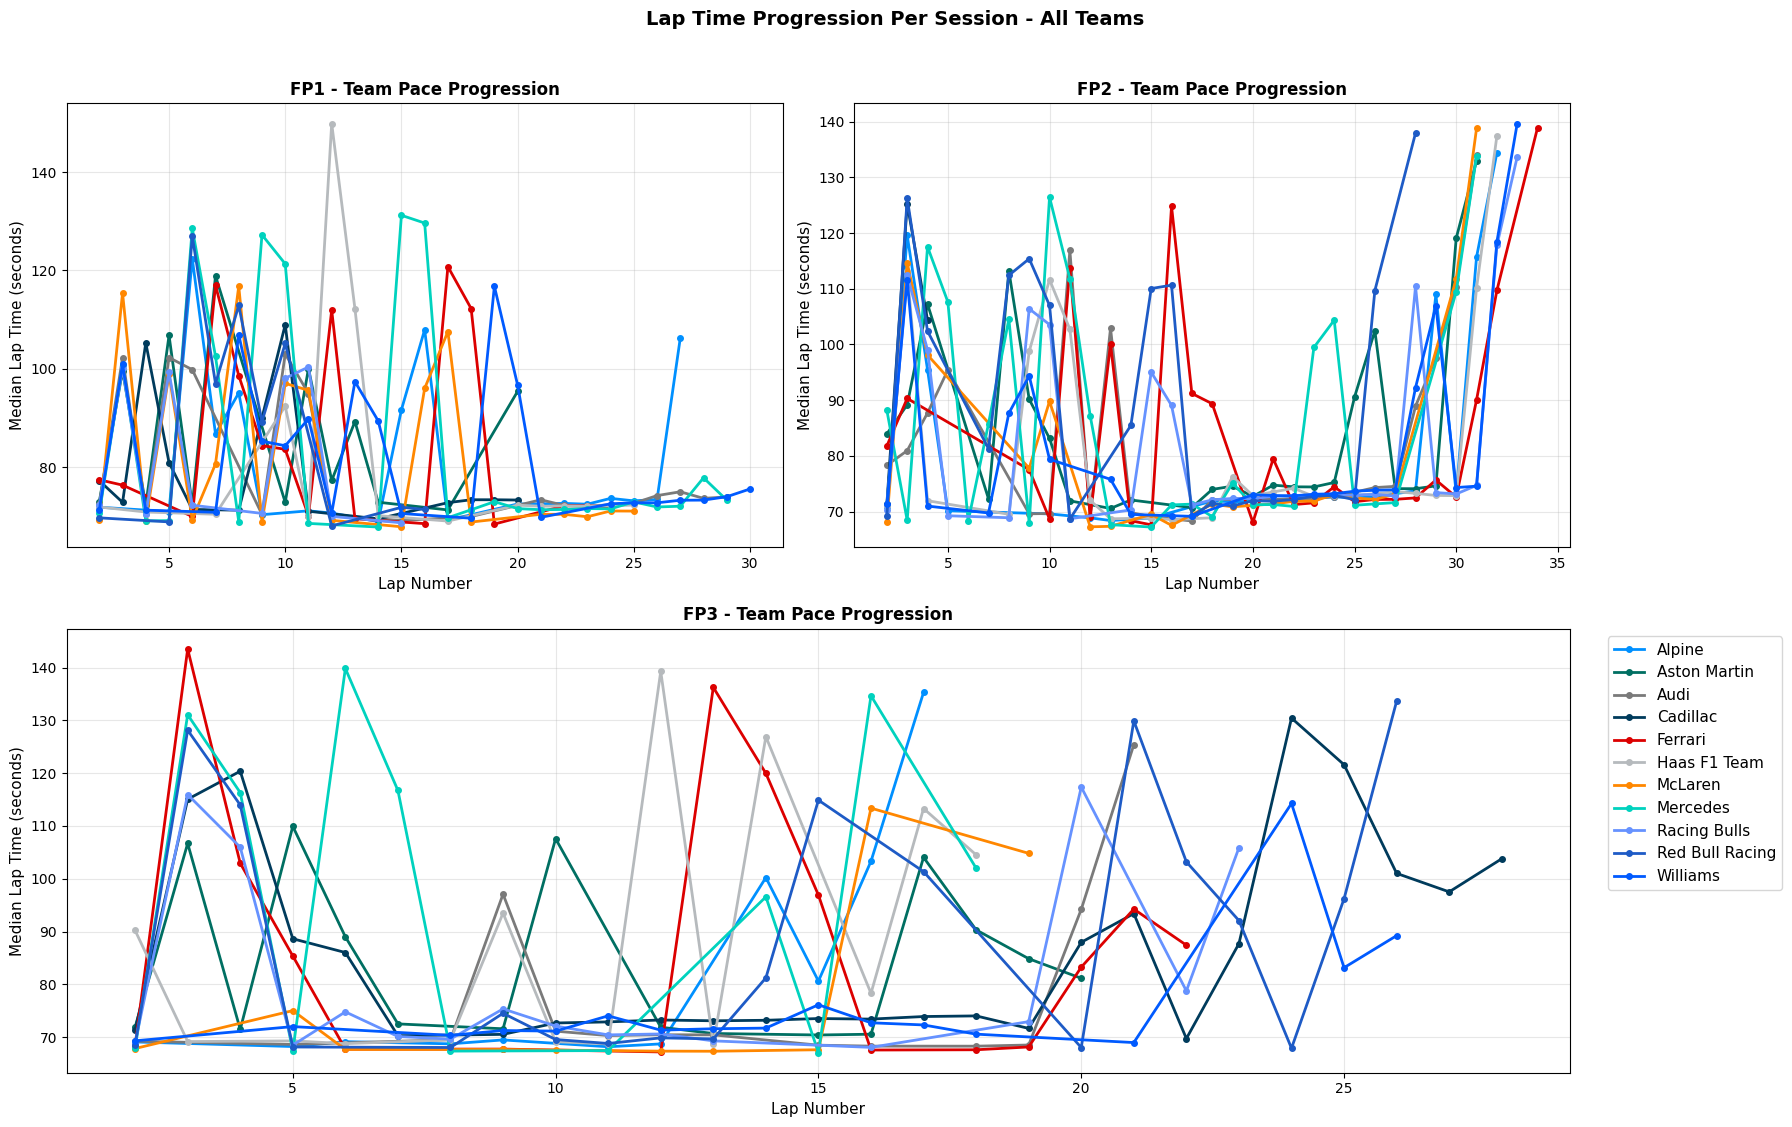

In [9]:
# Lap time progression by session and team (median pace by lap number)
layout = [['FP1', 'FP2'], ['FP3', 'FP3']]
fig, axes = plt.subplot_mosaic(layout, figsize=(18, 11))

for session_name in session_names:
    ax = axes[session_name]
    session_df = practice_df[practice_df['Session'] == session_name].copy()
    for team in sorted(practice_df['Team'].dropna().unique().tolist()):
        team_session = session_df[session_df['Team'] == team].copy()
        if team_session.empty:
            continue
        trend = (team_session.groupby('LapNumber', as_index=False)['LapTime'].median().sort_values('LapNumber'))
        ax.plot(trend['LapNumber'], trend['LapTime'], marker='o', linewidth=2, markersize=4, label=team,
                color=team_palette.get(team, 'gray')
                )
        
    ax.set_xlabel('Lap Number', fontsize=11)
    ax.set_ylabel('Median Lap Time (seconds)', fontsize=11)
    ax.set_title(f'{session_name} - Team Pace Progression', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Lap Time Progression Per Session - All Teams', fontsize=14, fontweight='bold', y=1.02)
plt.legend(fontsize=11, ncol=1, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
save_figure(fig, f"f1_{year}_{cache_gp}_lap_time_progression_by_session.png")

 ### Stint Pace Trends by Session

 Averaging lap time by stint smooths some of the lap-to-lap volatility and makes each team's run structure easier to compare. These plots are best read as context-aware indicators: they combine tyre state, fuel load evolution, and execution quality rather than representing a pure ranking of intrinsic pace.

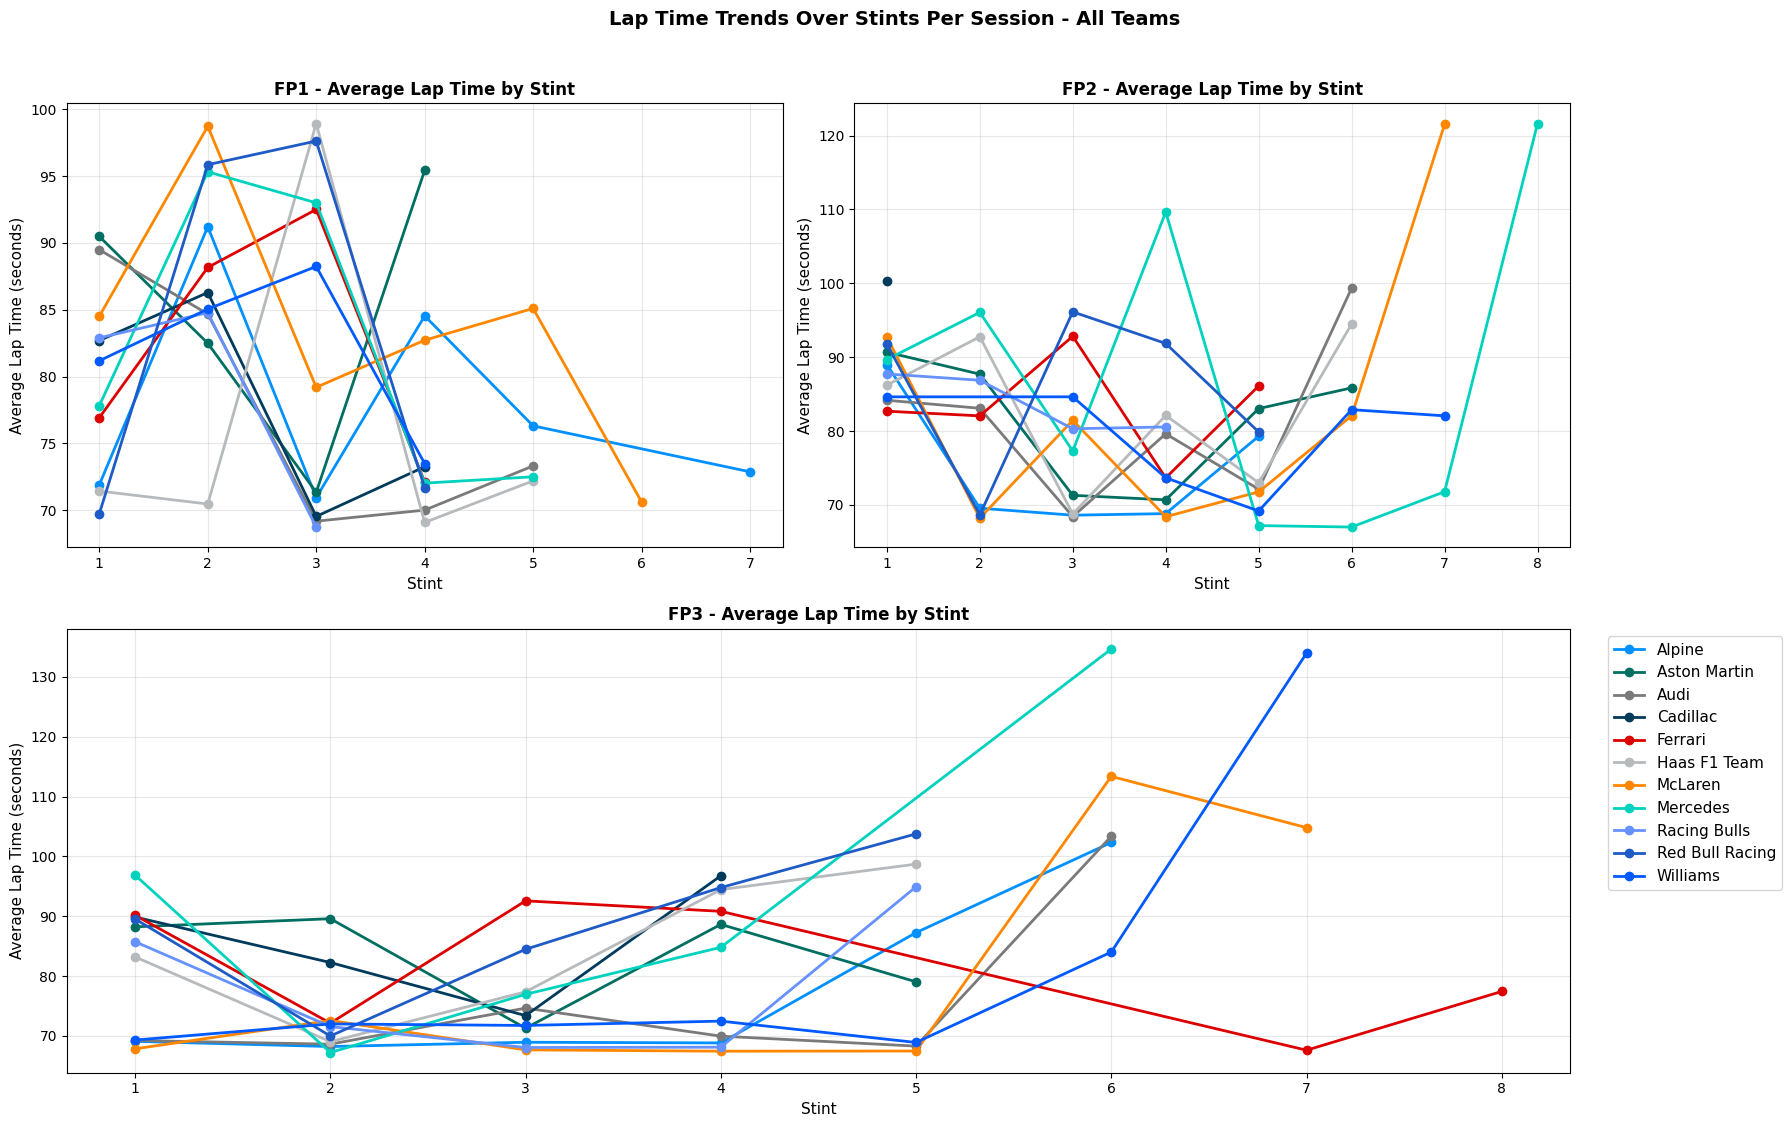

In [10]:
# Average lap time by stint for each session and team
layout = [['FP1', 'FP2'], ['FP3', 'FP3']]
fig, axes = plt.subplot_mosaic(layout, figsize=(18, 11))

for session_name in session_names:
    ax = axes[session_name]
    session_df = practice_df[practice_df['Session'] == session_name].copy()
    for team in sorted(practice_df['Team'].dropna().unique().tolist()):
        team_session = session_df[session_df['Team'] == team].copy()
        if team_session.empty or 'Stint' not in team_session.columns:
            continue
        team_session = team_session.dropna(subset=['Stint', 'LapTime'])
        if team_session.empty:
            continue
        stint_avg = (team_session.groupby('Stint', as_index=False)['LapTime'].mean().sort_values('Stint'))
        ax.plot(stint_avg['Stint'], stint_avg['LapTime'], marker='o', linewidth=2, markersize=6, 
                color=team_palette.get(team, 'gray'), label=team
                )

    ax.set_xlabel('Stint', fontsize=11)
    ax.set_ylabel('Average Lap Time (seconds)', fontsize=11)
    ax.set_title(f'{session_name} - Average Lap Time by Stint', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Lap Time Trends Over Stints Per Session - All Teams', fontsize=14, fontweight='bold', y=1.02)
plt.legend(fontsize=11, ncol=1, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
save_figure(fig, f"f1_{year}_{cache_gp}_stint_pace_trends.png")

 ### Speed Trap Trends by Session

 Speed-trap traces add straight-line context to the lap-time story. Consistent top-end speed can indicate efficiency or deployment strength, but isolated slow points often come from traffic, lift-and-coast, pit-lane transitions, or non-push laps.

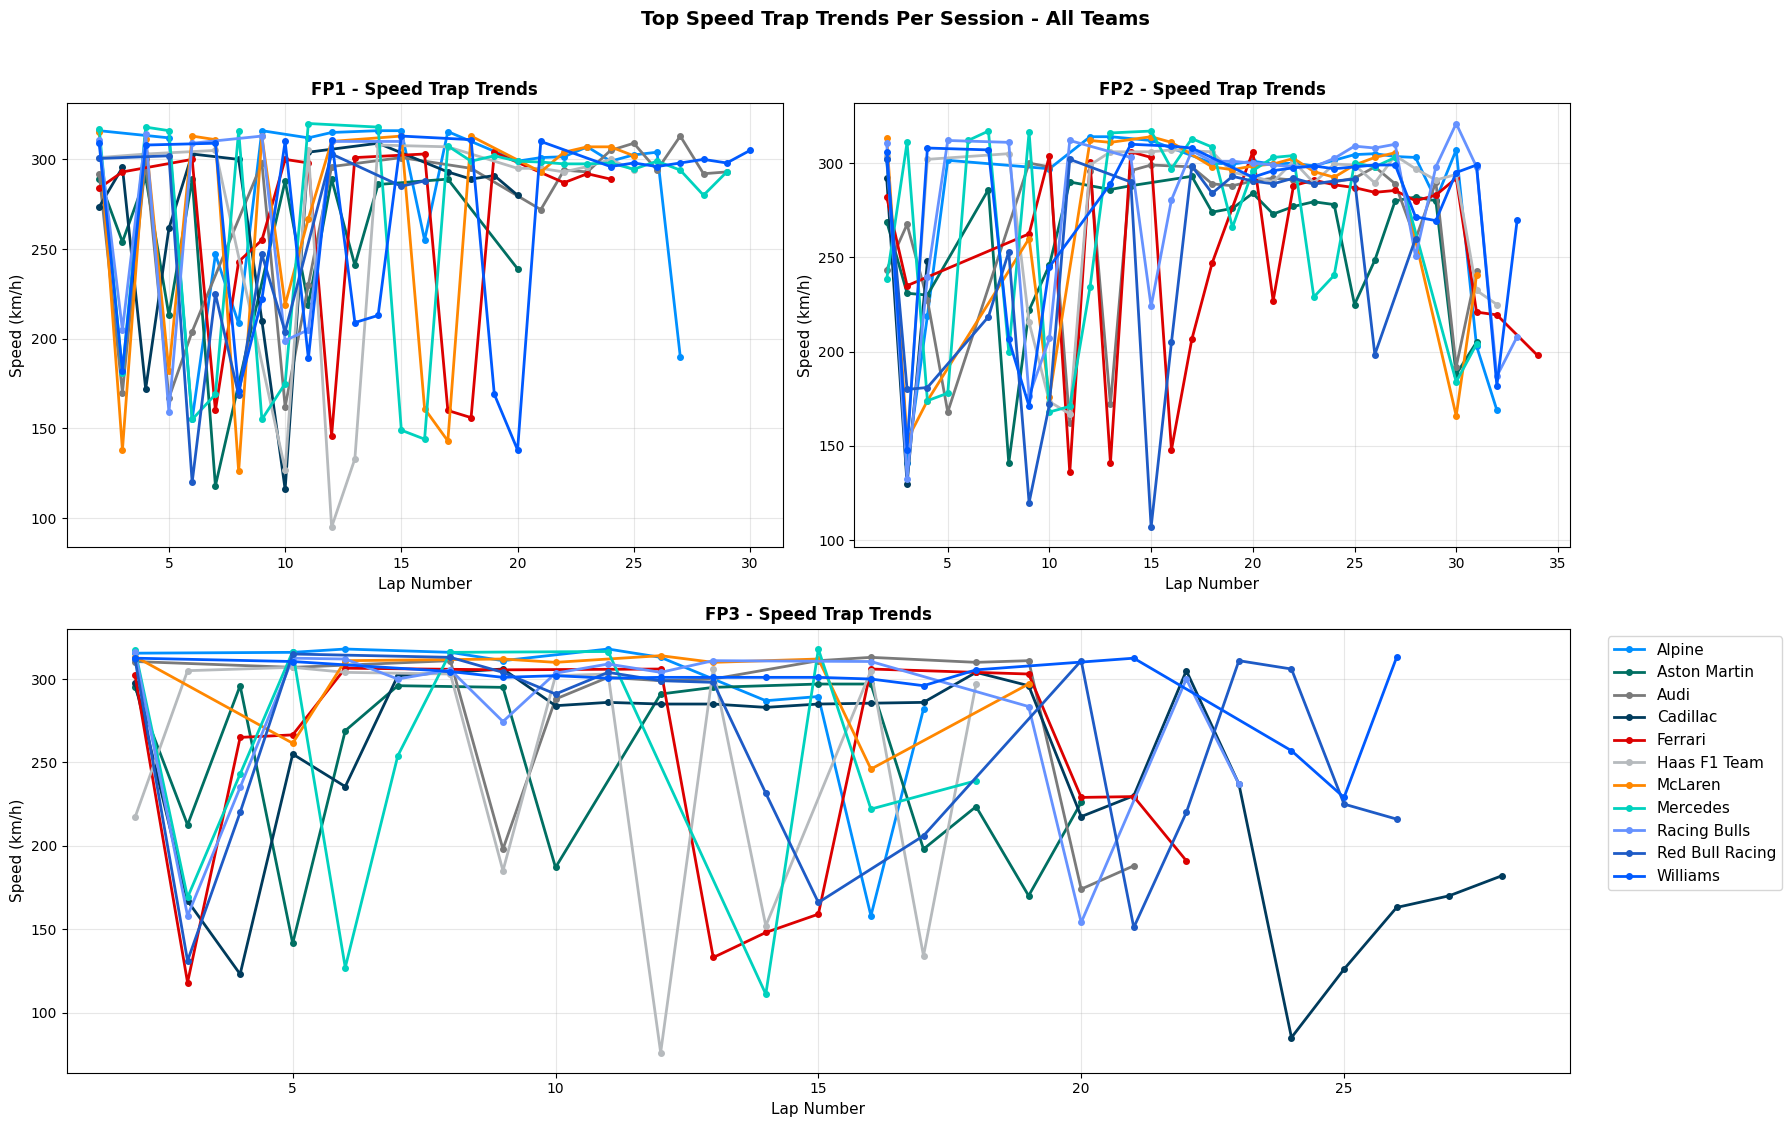

In [11]:
# Speed trap trends over sessions for all teams (median speed by lap number)
layout = [['FP1', 'FP2'], ['FP3', 'FP3']]
fig, axes = plt.subplot_mosaic(layout, figsize=(18, 11))

for session_name in session_names:
    ax = axes[session_name]
    session_df = practice_df[practice_df['Session'] == session_name].copy()
    for team in sorted(practice_df['Team'].dropna().unique().tolist()):
        team_session = session_df[session_df['Team'] == team].copy()
        if team_session.empty or 'SpeedST' not in team_session.columns:
            continue
        speed_trend = (team_session.dropna(subset=['SpeedST']).groupby('LapNumber', as_index=False)['SpeedST'].median()
                       .sort_values('LapNumber')
                       )
        if speed_trend.empty:
            continue
        ax.plot(speed_trend['LapNumber'], speed_trend['SpeedST'], marker='o', linewidth=2, markersize=4, label=team,
                color=team_palette.get(team, 'gray')
                )

    ax.set_xlabel('Lap Number', fontsize=11)
    ax.set_ylabel('Speed (km/h)', fontsize=11)
    ax.set_title(f'{session_name} - Speed Trap Trends', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Top Speed Trap Trends Per Session - All Teams', fontsize=14, fontweight='bold', y=1.02)
plt.legend(fontsize=11, ncol=1, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
save_figure(fig, f"f1_{year}_{cache_gp}_speed_trap_trends.png")

 ### Telemetry and Track Map



 This section compares the fastest available telemetry traces for all teams and overlays speed on the circuit map. The code intentionally skips missing or unreliable telemetry so the notebook can still run cleanly when a session pull does not return a full set of valid laps.

Telemetry plot skipped for Alpine: The data you are trying to access has not been loaded yet. See `Session.load`
Telemetry plot skipped for Aston Martin: The data you are trying to access has not been loaded yet. See `Session.load`
Telemetry plot skipped for Audi: The data you are trying to access has not been loaded yet. See `Session.load`
Telemetry plot skipped for Cadillac: The data you are trying to access has not been loaded yet. See `Session.load`
Telemetry plot skipped for Ferrari: The data you are trying to access has not been loaded yet. See `Session.load`
Telemetry plot skipped for Haas F1 Team: The data you are trying to access has not been loaded yet. See `Session.load`
Telemetry plot skipped for McLaren: The data you are trying to access has not been loaded yet. See `Session.load`
Telemetry plot skipped for Mercedes: The data you are trying to access has not been loaded yet. See `Session.load`
Telemetry plot skipped for Racing Bulls: The data you are trying to access has n

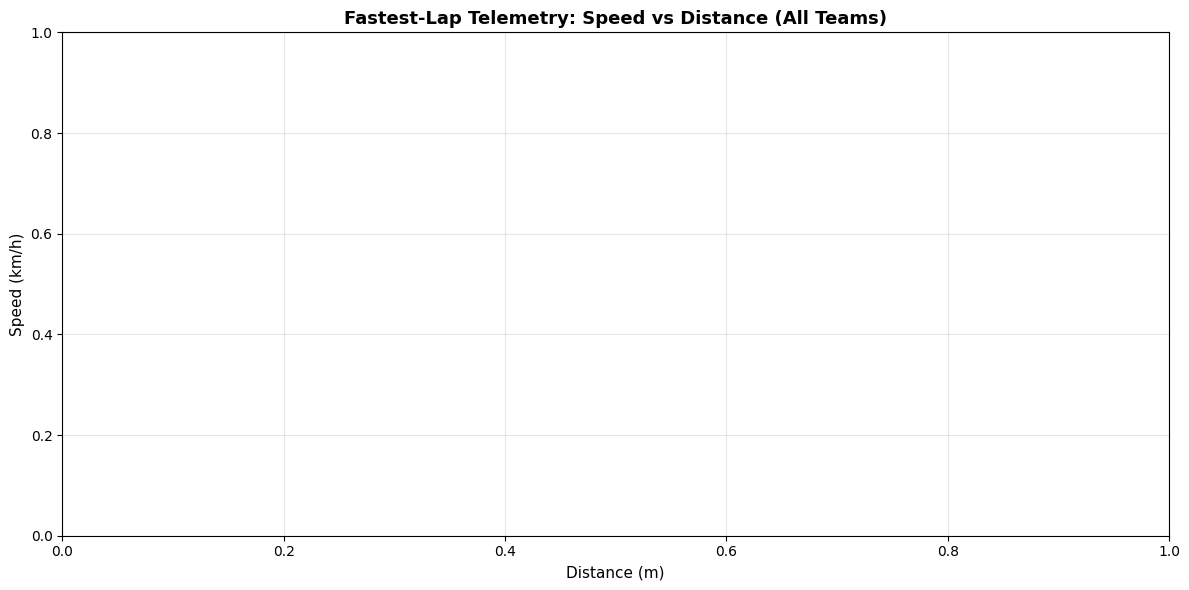

Track map skipped for Alpine: The data you are trying to access has not been loaded yet. See `Session.load`
Track map skipped for Aston Martin: The data you are trying to access has not been loaded yet. See `Session.load`
Track map skipped for Audi: The data you are trying to access has not been loaded yet. See `Session.load`
Track map skipped for Cadillac: The data you are trying to access has not been loaded yet. See `Session.load`
Track map skipped for Ferrari: The data you are trying to access has not been loaded yet. See `Session.load`
Track map skipped for Haas F1 Team: The data you are trying to access has not been loaded yet. See `Session.load`
Track map skipped for McLaren: The data you are trying to access has not been loaded yet. See `Session.load`
Track map skipped for Mercedes: The data you are trying to access has not been loaded yet. See `Session.load`
Track map skipped for Racing Bulls: The data you are trying to access has not been loaded yet. See `Session.load`
Track 

In [12]:
# Telemetry comparison and speed-colored track maps for fastest available laps
def lap_to_seconds(lap_time):
    return float(lap_time.total_seconds()) if pd.notna(lap_time) else np.nan

team_fastest = {}
for team in sorted(practice_df['Team'].dropna().unique().tolist()):
    candidate_laps = []
    for session_name in session_names:
        session = sessions_by_name.get(session_name)
        if session is None:
            print(f"Session {session_name} not found in startup cache; skipping in telemetry block.")
            continue

        try:
            team_laps = session.laps.pick_teams(team).pick_quicklaps()
            if team_laps is None or len(team_laps) == 0:
                continue

            fastest = team_laps.pick_fastest()
            if fastest is not None and pd.notna(fastest['LapTime']):
                candidate_laps.append((session_name, fastest))
        except Exception as exc:
            print(f"Skipping {team} {session_name}: {exc}")

    if len(candidate_laps) == 0:
        print(f"No reliable telemetry lap found for {team} yet. Keeping logic for future reruns.")
        continue

    best_session, best_lap = min(candidate_laps, key=lambda item: item[1]['LapTime'])
    team_fastest[team] = {'session': best_session, 'lap': best_lap}

if len(team_fastest) == 0:
    print('No telemetry laps available to plot right now.')
else:
    # Speed vs distance telemetry traces
    fig, ax = plt.subplots(figsize=(12, 6))
    summary_rows = []

    for team, payload in team_fastest.items():
        lap = payload['lap']
        session_name = payload['session']
        try:
            telemetry = lap.get_car_data().add_distance()
            ax.plot(telemetry['Distance'], telemetry['Speed'], color=team_palette.get(team, 'gray'), linewidth=2,
                    label=f"{team} - {lap['Driver']}"
                    )
            summary_rows.append({'Team': team, 'Driver': lap['Driver'], 'Session': session_name, 
                                 'LapTimeSec': lap_to_seconds(lap['LapTime'])
                                 })
        except Exception as exc:
            print(f"Telemetry plot skipped for {team}: {exc}")

    ax.set_title('Fastest-Lap Telemetry: Speed vs Distance (All Teams)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Distance (m)', fontsize=11)
    ax.set_ylabel('Speed (km/h)', fontsize=11)
    ax.grid(alpha=0.3)
    if summary_rows:
        ax.legend(fontsize=11, bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    plt.show()
    save_figure(fig, f"f1_{year}_{cache_gp}_fastest_telemetry_speed_vs_distance.png")

    if summary_rows:
        telemetry_summary = pd.DataFrame(summary_rows).sort_values('LapTimeSec').reset_index(drop=True)
        print('Telemetry fastest-lap summary:')
        print(telemetry_summary.to_string(index=False))

    # Track map colored by speed for the 3 fastest teams in one row
    map_data = {}
    for team, payload in team_fastest.items():
        lap = payload['lap']
        try:
            car = lap.get_car_data()[['Time', 'Speed']].copy().sort_values('Time')
            pos = lap.get_pos_data()[['Time', 'X', 'Y']].copy().sort_values('Time')

            if car.empty or pos.empty:
                print(f"Track map skipped for {team}: empty telemetry frames")
                continue

            merged = pd.merge_asof(pos, car, on='Time', direction='nearest')
            merged = merged.dropna(subset=['X', 'Y', 'Speed'])
            if len(merged) < 2:
                print(f"Track map skipped for {team}: insufficient merged telemetry points")
                continue

            map_data[team] = {'x': merged['X'].to_numpy(), 'y': merged['Y'].to_numpy(),
                              'speed': merged['Speed'].to_numpy(), 'driver': lap['Driver'],
                              'lap_time_sec': lap_to_seconds(lap['LapTime'])
                              }
        except Exception as exc:
            print(f"Track map skipped for {team}: {exc}")

    if len(map_data) == 0:
        print('No track-map telemetry available to draw right now.')
    else:
        top_teams = sorted(map_data.keys(), key=lambda t: map_data[t]['lap_time_sec'])[:3]

        n_teams = len(top_teams)
        fig, axes = plt.subplots(1, n_teams, figsize=(5.6 * n_teams, 5.2), constrained_layout=True)
        axes_flat = np.atleast_1d(axes).ravel()

        global_speed_min = min(map_data[t]['speed'].min() for t in top_teams)
        global_speed_max = max(map_data[t]['speed'].max() for t in top_teams)
        norm = plt.Normalize(global_speed_min, global_speed_max)

        for idx, team in enumerate(top_teams):
            ax = axes_flat[idx]
            x = map_data[team]['x']
            y = map_data[team]['y']
            speed = map_data[team]['speed']
            driver = map_data[team]['driver']

            points = np.array([x, y]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)
            lc = LineCollection(segments, cmap='viridis', norm=norm)
            lc.set_array(speed[:-1])
            lc.set_linewidth(3.8)

            ax.add_collection(lc)
            ax.set_aspect('equal', 'box')
            ax.set_xlim(x.min() - 100, x.max() + 100)
            ax.set_ylim(y.min() - 100, y.max() + 100)
            ax.axis('off')
            ax.set_title(f"{team} ({driver}) - {map_data[team]['lap_time_sec']:.3f}s", fontsize=10.5, fontweight='bold')

        sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=axes_flat, fraction=0.03, pad=0.02, shrink=0.92)
        cbar.set_label('Speed (km/h)')

        fig.suptitle('Speed-Colored Track Map - Top 3 Fastest Teams', fontsize=14, fontweight='bold')
        plt.show()
        save_figure(fig, f"f1_{year}_{cache_gp}_speed_colored_track_map.png")

### Tyre Compound Thermal Degradation

The correlation heatmap quantifies the linear relationship between TrackTemp, AirTemp, Humidity, TyreLife, and LapTime. A positive correlation between TrackTemp and LapTime would indicate that hotter conditions slow the car, consistent with increased tyre graining or blistering on the softer compounds. TyreLife is expected to show the strongest positive correlation with LapTime, as degradation is the dominant driver of lap time loss across a stint.

The scatter plot overlays TyreLife against TrackTemp with LapTime encoded as colour. Clusters of dark points (slower laps) at high TyreLife and high TrackTemp would confirm that thermal stress compounds degradation beyond what tyre age alone explains — the interaction effect that motivated adding these features to the degradation model.

The per-compound bar charts bin TrackTemp into six equal-width bands and plot the median lap time within each band. A consistent upward trend across bands for SOFT tyres would suggest that the compound is more thermally sensitive than MEDIUM or HARD, which is expected given its lower glass transition temperature and thinner tread gauge. Flat or non-monotonic trends would indicate that thermal variance at this circuit is within the compound's operating window and contributes little predictive value to the model.

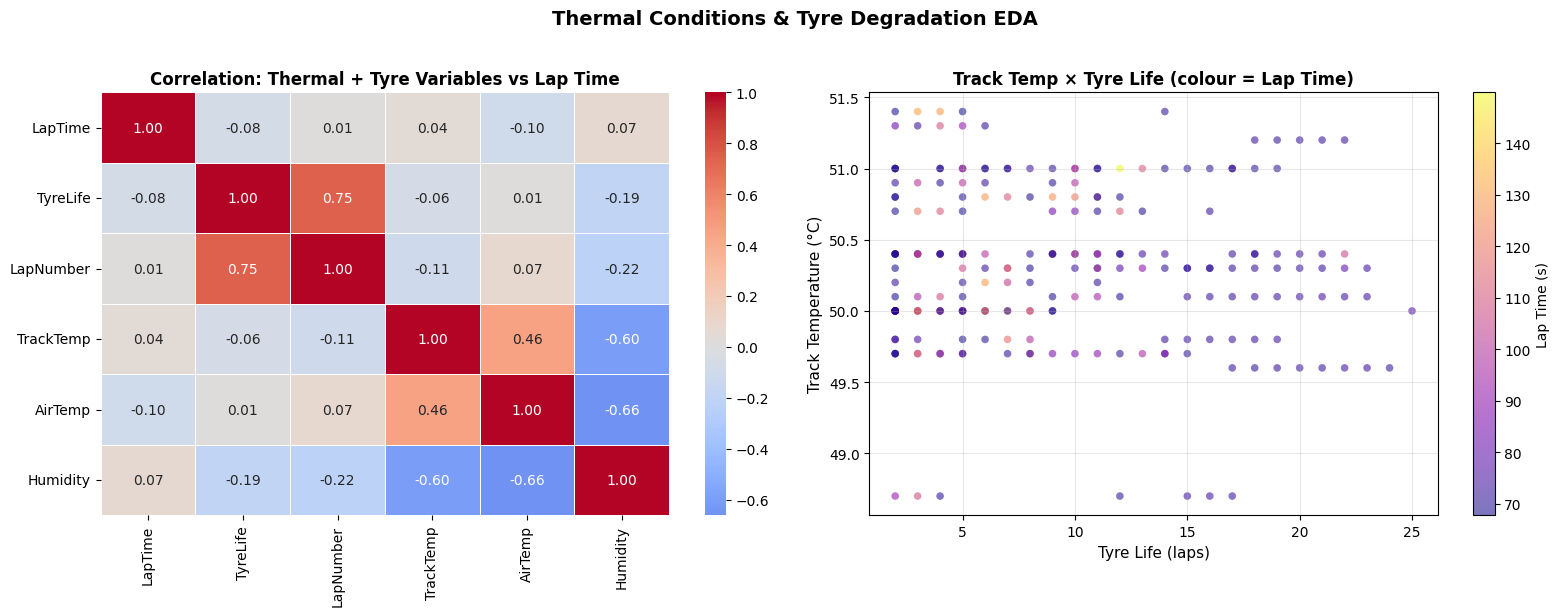

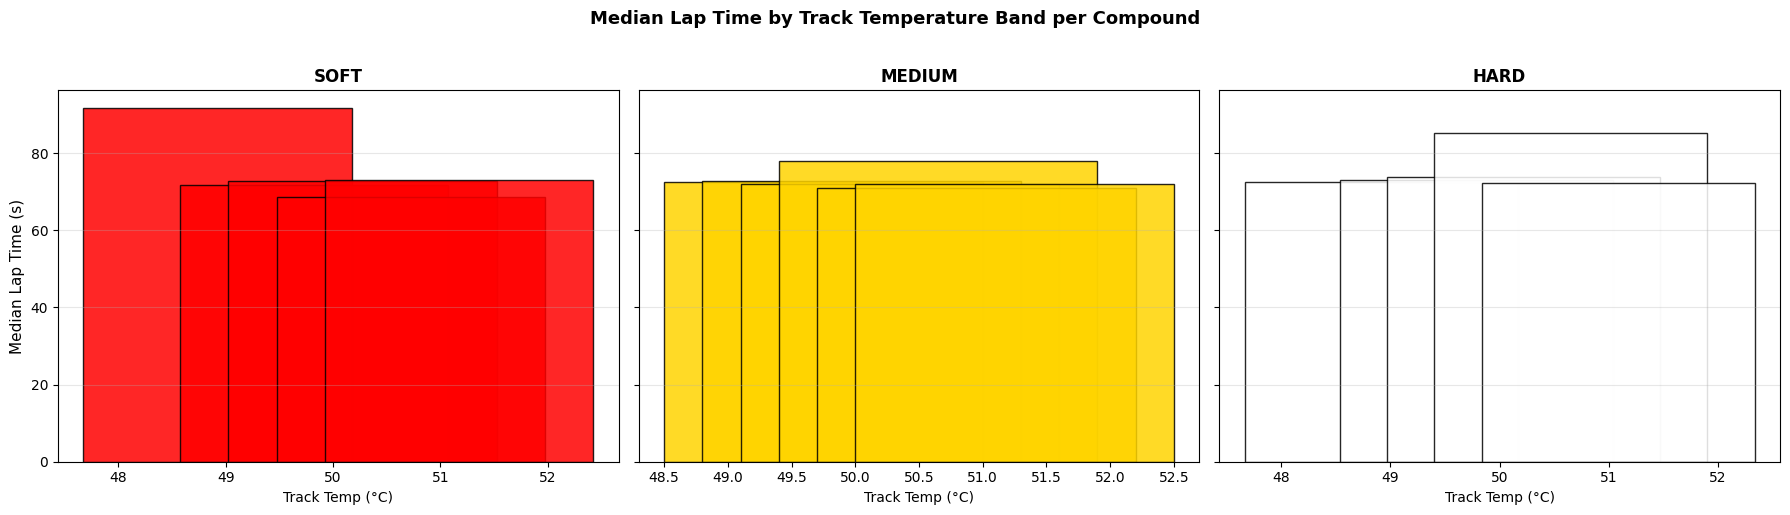

Thermal correlation with LapTime:
TrackTemp    0.043
AirTemp     -0.095
Humidity     0.065


In [13]:
# Thermal & Tyre Degradation EDA
thermal_cols_present = [c for c in ['TrackTemp', 'AirTemp', 'Humidity']
                        if c in practice_df.columns and practice_df[c].notna().any()]

if thermal_cols_present:
    deg_eda_df = (practice_df[practice_df['Compound'].isin(COMPOUNDS) &
                              practice_df['LapTime'].notna() &
                              practice_df['TyreLife'].notna()]
                  .copy())

    # Correlation heatmap: thermal + tyre inputs vs lap time
    corr_cols = ['LapTime', 'TyreLife', 'LapNumber'] + thermal_cols_present
    corr_matrix = deg_eda_df[corr_cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, ax=axes[0])
    axes[0].set_title('Correlation: Thermal + Tyre Variables vs Lap Time',
                      fontsize=12, fontweight='bold')

    # TrackTemp × TyreLife scatter coloured by LapTime per compound
    scatter_df = deg_eda_df.dropna(subset=['TrackTemp'] + ['LapTime', 'TyreLife'])
    sc = axes[1].scatter(scatter_df['TyreLife'], scatter_df['TrackTemp'],
                         c=scatter_df['LapTime'], cmap='plasma',
                         alpha=0.55, s=30, edgecolors='none')
    plt.colorbar(sc, ax=axes[1], label='Lap Time (s)')
    axes[1].set_xlabel('Tyre Life (laps)', fontsize=11)
    axes[1].set_ylabel('Track Temperature (°C)', fontsize=11)
    axes[1].set_title('Track Temp × Tyre Life (colour = Lap Time)',
                      fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)

    plt.suptitle('Thermal Conditions & Tyre Degradation EDA',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    save_figure(fig, f"f1_{year}_{cache_gp}_thermal_degradation_eda.png")

    # Per-compound: median lap time binned by TrackTemp
    fig, axes = plt.subplots(1, len(COMPOUNDS), figsize=(18, 5), sharey=True)
    for idx, compound in enumerate(COMPOUNDS):
        comp_df = deg_eda_df[deg_eda_df['Compound'] == compound].dropna(subset=['TrackTemp'])
        if comp_df.empty:
            axes[idx].set_visible(False)
            continue
        comp_df['TempBin'] = pd.cut(comp_df['TrackTemp'], bins=6)
        binned = comp_df.groupby('TempBin', observed=True)['LapTime'].median().reset_index()
        binned['TempMid'] = binned['TempBin'].apply(lambda x: x.mid)
        axes[idx].bar(binned['TempMid'].astype(float), binned['LapTime'],
                      width=2.5, color=tyre_palette.get(compound, 'gray'),
                      edgecolor='black', alpha=0.85)
        axes[idx].set_title(f'{compound}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Track Temp (°C)', fontsize=10)
        axes[idx].grid(alpha=0.3, axis='y')

    axes[0].set_ylabel('Median Lap Time (s)', fontsize=11)
    plt.suptitle('Median Lap Time by Track Temperature Band per Compound',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    save_figure(fig, f"f1_{year}_{cache_gp}_laptime_by_tracktemp_compound.png")

    print("Thermal correlation with LapTime:")
    print(corr_matrix['LapTime'][thermal_cols_present].round(3).to_string())
else:
    print("No thermal columns available in practice_df — skipping thermal EDA.")

 ### Tyre Compound Performance

 Compound-level distributions show whether pace and consistency change when teams switch between SOFT, MEDIUM, and HARD tyres. Even when average lap time is similar, the spread can differ sharply because warm-up behavior, push-lap intent, and degradation profiles are not the same across compounds.

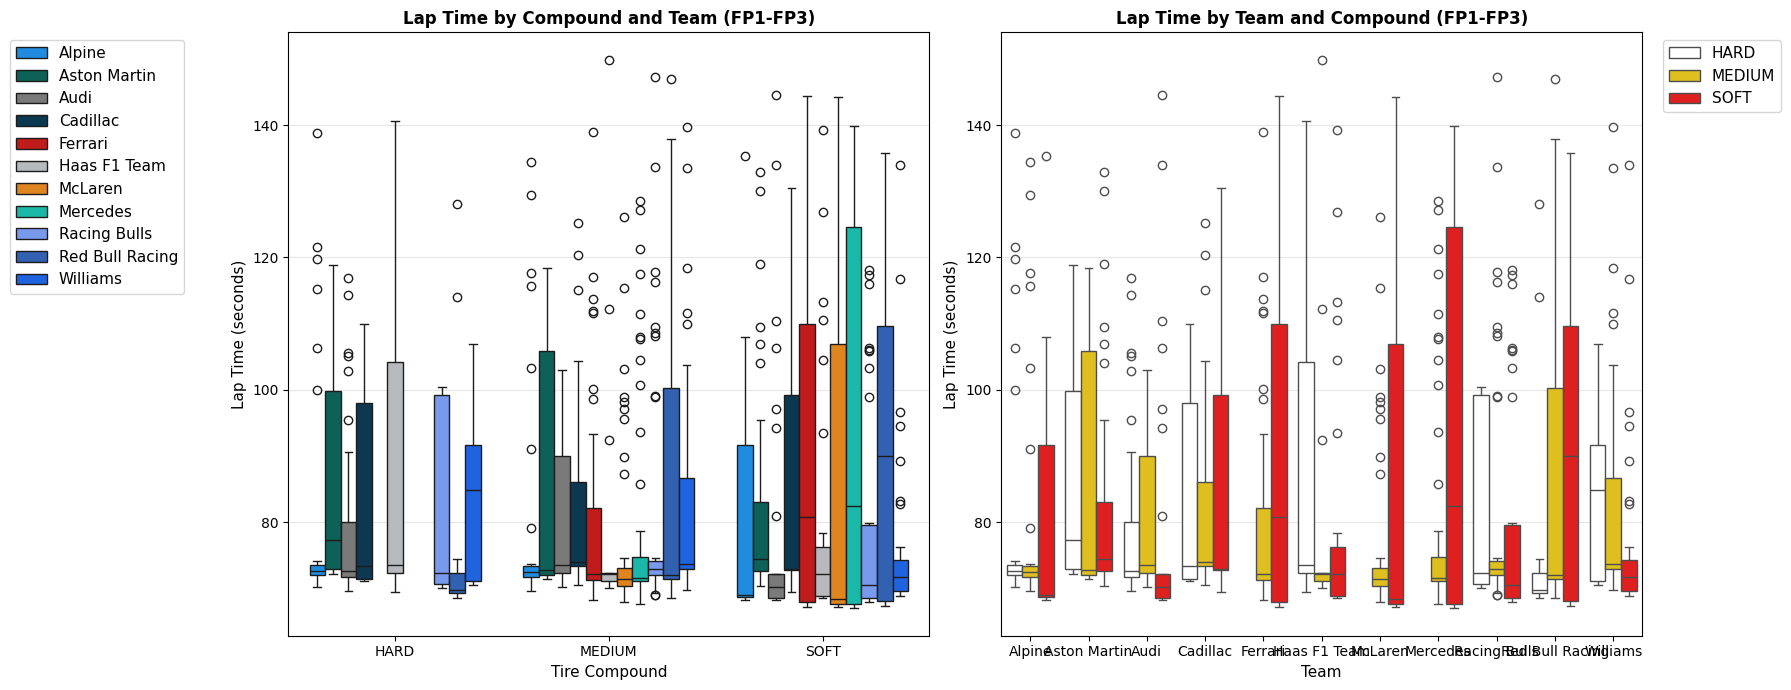

Average Lap Time by Team and Compound:
                            mean     std  count
Team            Compound                       
Alpine          HARD      81.112  19.090     30
                MEDIUM    80.364  18.284     32
                SOFT      79.240  18.642     21
Aston Martin    HARD      86.853  16.930     11
                MEDIUM    87.468  17.379     29
                SOFT      83.019  18.345     31
Audi            HARD      79.733  14.453     31
                MEDIUM    80.331  13.019     18
                SOFT      79.176  20.358     29
Cadillac        HARD      83.978  16.207     14
                MEDIUM    83.548  18.854     18
                SOFT      83.952  17.680     27
Ferrari         MEDIUM    80.153  16.547     42
                SOFT      89.187  25.365     35
Haas F1 Team    HARD      87.747  23.159     27
                MEDIUM    81.511  22.941     14
                SOFT      79.871  19.502     29
McLaren         MEDIUM    77.400  13.815     42
 

In [14]:
# Tire compound performance across all teams
practice_session_df = practice_df[practice_df['Session'].isin(session_names)].copy()
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Lap time by compound, segmented by team
compound_order = sorted([c for c in practice_session_df['Compound'].dropna().unique()])
sns.boxplot(data=practice_session_df[practice_session_df['Compound'].notna()], x='Compound', y='LapTime', hue='Team', order=compound_order,
            hue_order=sorted(box_data['Team'].dropna().unique().tolist()), palette=team_palette, ax=axes[0]
            )

axes[0].set_xlabel('Tire Compound', fontsize=11)
axes[0].set_ylabel('Lap Time (seconds)', fontsize=11)
axes[0].set_title('Lap Time by Compound and Team (FP1-FP3)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
axes[0].legend(fontsize=11, ncol=1, bbox_to_anchor=(-0.15, 1), loc='upper right')

# Lap time by team, segmented by compound
team_order = sorted(practice_session_df['Team'].dropna().unique().tolist())
sns.boxplot(data=practice_session_df[practice_session_df['Compound'].notna()], x='Team', y='LapTime', hue='Compound', order=team_order,
            hue_order=compound_order, palette={c: tyre_palette.get(c, 'gray') for c in compound_order}, ax=axes[1]
            )

axes[1].set_xlabel('Team', fontsize=11)
axes[1].set_ylabel('Lap Time (seconds)', fontsize=11)
axes[1].set_title('Lap Time by Team and Compound (FP1-FP3)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
axes[1].legend(fontsize=11, ncol=1, bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
compound_performance_summary = (practice_session_df[practice_session_df['Compound'].notna()]
                                .groupby(['Team', 'Compound'])['LapTime'].agg(['mean', 'std', 'count'])
                                .reset_index())
plt.show()
save_figure(fig, f"f1_{year}_{cache_gp}_compound_performance.png")

print('Average Lap Time by Team and Compound:')
print(practice_session_df.groupby(['Team', 'Compound'])['LapTime'].agg(['mean', 'std', 'count']).round(3).sort_index())

 ## Machine Learning Analysis

 This section builds supervised regression models to predict all-team lap time from lap context, tyre state, straight-line speed, and driver-team identifiers. Performance is evaluated with a baseline benchmark plus MAE, RMSE, and R2 on a held-out test split.

 ### Qualifying Model Pipeline

 The pipeline keeps preprocessing and model fitting in one reproducible object. Numeric features are passed through directly, categorical variables are one-hot encoded, and ensemble regressors are trained on a filtered qualifying-oriented subset of the practice data.



 The current implementation focuses the training set on SOFT-tyre laps marked as fresh-tyre runs before fitting the models.

In [15]:
def qualifying_model_pipeline():
    print("Starting qualifying model pipeline")

    # Use all-team data and keep columns needed for modeling
    model_df = pd.concat([practice_df, pyear_qualifying_df], ignore_index=True)

    # Reduce extreme outliers that hurt variance-based metrics like R^2
    low_q, high_q = model_df['LapTime'].quantile([0.05, 0.95])
    model_df = model_df[(model_df['LapTime'] >= low_q) & (model_df['LapTime'] <= high_q)].copy()

    # Train only on soft-compound laps
    required_filter_cols = ['Compound']
    missing_filter_cols = [col for col in required_filter_cols if col not in model_df.columns]
    if missing_filter_cols:
        raise KeyError(f"Missing required filter column(s): {missing_filter_cols}")

    soft_mask = model_df['Compound'].astype(str).str.upper() == 'SOFT'
    fresh_mask = model_df['FreshTyre'].astype(str) == 'True'
    model_df = model_df[soft_mask & fresh_mask].copy()
    print(f"Rows after SOFT and fresh filter: {len(model_df)}")
    
    if model_df.empty:
        raise ValueError("No qualifying laps remain after the SOFT-compound filter.")

    if 'Session' not in model_df.columns:
        raise KeyError("Missing required column: Session")

    # Define features and target (add telemetry/sector signals when available)
    base_num_features = ['LapNumber', 'TyreLife', 'Stint']
    base_cat_features = ['Compound', 'Driver', 'Team', 'Session', 'TrackStatus']
    telemetry_candidate_features = ['SpeedST','SpeedI1', 'SpeedI2', 'SpeedFL', 'Throttle', 'Brake']

    telemetry_features = [
        col for col in telemetry_candidate_features
        if col in model_df.columns and pd.api.types.is_numeric_dtype(model_df[col])
    ]
    numeric_features = list(dict.fromkeys(base_num_features + telemetry_features))
    categorical_features = [col for col in base_cat_features if col in model_df.columns]
    features = numeric_features + categorical_features
    target = 'LapTime'

    # Keep rows where required columns exist and are non-null
    required_cols = features + [target]
    model_df = model_df[required_cols].dropna().copy()
    if model_df.empty:
        raise ValueError("No qualifying laps remain after dropping missing feature or target values.")

    # Split into features and target
    X = model_df[features].copy()
    y = model_df[target].copy()

    # One-hot encode categorical features
    preprocessor = ColumnTransformer(
        transformers=[('num', 'passthrough', numeric_features),
                      ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
                      ])

    print("Preprocessing pipeline created")

    # Use stratification only when every session has enough examples
    stratify_series = None
    session_counts = X['Session'].value_counts()
    if len(session_counts) > 1 and session_counts.min() >= 2:
        stratify_series = X['Session']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=324, stratify=stratify_series)

    # Baseline suite for validation context
    train_df = X_train.copy()
    train_df['LapTime'] = y_train.values
    test_df = X_test.copy().reset_index(drop=True)

    mean_baseline = DummyRegressor(strategy='mean')
    mean_baseline.fit(X_train[numeric_features], y_train)
    mean_baseline_predictions = mean_baseline.predict(X_test[numeric_features])
    mean_baseline_mae = mean_absolute_error(y_test, mean_baseline_predictions)
    mean_baseline_rmse = np.sqrt(mean_squared_error(y_test, mean_baseline_predictions))
    mean_baseline_r2 = r2_score(y_test, mean_baseline_predictions)

    # Create model pipelines
    rf_model = Pipeline(
        steps=[('preprocessor', preprocessor),
               ('rf_regressor', RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=324))
               ])

    gb_model = Pipeline(
        steps=[('preprocessor', preprocessor),
               ('gb_regressor', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=324))
               ])

    xgb_model = Pipeline(
        steps=[('preprocessor', preprocessor),
               ('xgb_regressor', XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=324, verbosity=0))
               ])

    # Train model and make predictions
    print("Training Random Forest model")
    rf_model.fit(X_train, y_train)
    rf_predictions = rf_model.predict(X_test)

    print("Training Gradient Boosting model")
    gb_model.fit(X_train, y_train)
    gb_predictions = gb_model.predict(X_test)

    print("Training XGBoost model")
    xgb_model.fit(X_train, y_train)
    xgb_predictions = xgb_model.predict(X_test)

    # Calculate model metrics
    rf_mae = mean_absolute_error(y_test, rf_predictions)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
    rf_r2 = r2_score(y_test, rf_predictions)

    gb_mae = mean_absolute_error(y_test, gb_predictions)
    gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
    gb_r2 = r2_score(y_test, gb_predictions)

    xgb_mae = mean_absolute_error(y_test, xgb_predictions)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
    xgb_r2 = r2_score(y_test, xgb_predictions)

    # Driver-level diagnostics: keep MAE columns for reference, but select best model by fastest predicted lap.
    driver_eval_df = X_test[['Driver', 'Team', 'Session']].copy().reset_index(drop=True)
    driver_eval_df['ActualLapTime'] = y_test.reset_index(drop=True)
    driver_eval_df['RF_Pred'] = rf_predictions
    driver_eval_df['GB_Pred'] = gb_predictions
    driver_eval_df['XGB_Pred'] = xgb_predictions
    driver_eval_df['RF_AbsErr'] = (driver_eval_df['ActualLapTime'] - driver_eval_df['RF_Pred']).abs()
    driver_eval_df['GB_AbsErr'] = (driver_eval_df['ActualLapTime'] - driver_eval_df['GB_Pred']).abs()
    driver_eval_df['XGB_AbsErr'] = (driver_eval_df['ActualLapTime'] - driver_eval_df['XGB_Pred']).abs()

    q_driver_mae = (driver_eval_df.groupby('Driver', as_index=False)[['RF_AbsErr', 'GB_AbsErr', 'XGB_AbsErr', 'RF_Pred', 'GB_Pred', 'XGB_Pred']].mean()
                    .rename(columns={'RF_AbsErr': 'RF_MAE',
                                     'GB_AbsErr': 'GB_MAE',
                                     'XGB_AbsErr': 'XGB_MAE',
                                     'RF_Pred': 'RF_PredMean',
                                     'GB_Pred': 'GB_PredMean',
                                     'XGB_Pred': 'XGB_PredMean'
                                     }))

    q_driver_mae['BestModel'] = q_driver_mae[['RF_PredMean', 'GB_PredMean', 'XGB_PredMean']].idxmin(axis=1).map({
        'RF_PredMean': 'Random Forest Regression',
        'GB_PredMean': 'Gradient Boosting Regression',
        'XGB_PredMean': 'XGBoost Regression'
        })
    q_driver_mae['BestPredLapTime'] = q_driver_mae[['RF_PredMean', 'GB_PredMean', 'XGB_PredMean']].min(axis=1)
    q_driver_mae = q_driver_mae.sort_values('BestPredLapTime').reset_index(drop=True)

    print("Model training completed")

    return {
        'q_model_df': model_df,
        'q_features': features,
        'q_X_train': X_train,
        'q_X_test': X_test,
        'q_y_train': y_train,
        'q_y_test': y_test,
        'q_mean_baseline_predictions': mean_baseline_predictions,
        'q_mean_baseline_mae': mean_baseline_mae,
        'q_mean_baseline_rmse': mean_baseline_rmse,
        'q_mean_baseline_r2': mean_baseline_r2,
        'q_rf_model': rf_model,
        'q_rf_predictions': rf_predictions,
        'q_rf_mae': rf_mae,
        'q_rf_rmse': rf_rmse,
        'q_rf_r2': rf_r2,
        'q_gb_model': gb_model,
        'q_gb_predictions': gb_predictions,
        'q_gb_mae': gb_mae,
        'q_gb_rmse': gb_rmse,
        'q_gb_r2': gb_r2,
        'q_xgb_model': xgb_model,
        'q_xgb_predictions': xgb_predictions,
        'q_xgb_mae': xgb_mae,
        'q_xgb_rmse': xgb_rmse,
        'q_xgb_r2': xgb_r2,
        'q_driver_eval_df': driver_eval_df,
        'q_driver_mae': q_driver_mae
    }

In [16]:
# Run the model pipeline
model_results = qualifying_model_pipeline()

# Extract results
q_model_df = model_results['q_model_df']
q_features = model_results['q_features']
q_X_train = model_results['q_X_train']
q_X_test = model_results['q_X_test']
q_y_train = model_results['q_y_train']
q_y_test = model_results['q_y_test']
q_mean_baseline_predictions = model_results['q_mean_baseline_predictions']
q_mean_baseline_mae = model_results['q_mean_baseline_mae']
q_mean_baseline_rmse = model_results['q_mean_baseline_rmse']
q_mean_baseline_r2 = model_results['q_mean_baseline_r2']
q_rf_model = model_results['q_rf_model']
q_rf_predictions = model_results['q_rf_predictions']
q_rf_mae = model_results['q_rf_mae']
q_rf_rmse = model_results['q_rf_rmse']
q_rf_r2 = model_results['q_rf_r2']
q_gb_model = model_results['q_gb_model']
q_gb_predictions = model_results['q_gb_predictions']
q_gb_mae = model_results['q_gb_mae']
q_gb_rmse = model_results['q_gb_rmse']
q_gb_r2 = model_results['q_gb_r2']
q_xgb_model = model_results['q_xgb_model']
q_xgb_predictions = model_results['q_xgb_predictions']
q_xgb_mae = model_results['q_xgb_mae']
q_xgb_rmse = model_results['q_xgb_rmse']
q_xgb_r2 = model_results['q_xgb_r2']
q_driver_eval_df = model_results['q_driver_eval_df']
q_driver_mae = model_results['q_driver_mae']

Starting qualifying model pipeline
Rows after SOFT and fresh filter: 152
Preprocessing pipeline created
Training Random Forest model
Training Gradient Boosting model
Training XGBoost model
Model training completed


In [17]:
# Compare the performance of all trained models from the pipeline
perform_df = pd.DataFrame({
    'Model': ['Mean Baseline','Random Forest Regression', 'Gradient Boosting Regression' , 'XGBoost Regression'],
    'Mean Absolute Error (MAE)': [q_mean_baseline_mae, q_rf_mae, q_gb_mae, q_xgb_mae],
    'Root Absolute Error (RMSE)': [q_mean_baseline_rmse, q_rf_rmse, q_gb_rmse, q_xgb_rmse],
    'R² Score': [q_mean_baseline_r2, q_rf_r2, q_gb_r2, q_xgb_r2]
})
perform_df['Mean Absolute Error (MAE)'] = perform_df['Mean Absolute Error (MAE)'].apply(lambda x: f"{x:,.3f} sec")
perform_df['Root Absolute Error (RMSE)'] = perform_df['Root Absolute Error (RMSE)'].apply(lambda x: f"{x:,.3f} sec")
perform_df['R² Score'] = perform_df['R² Score'].apply(lambda x: f"{x:.3f}")

print("Qualifying Pipeline Model Comparison:")
print(perform_df.to_string(index=False))

# Driver-level model selection now uses the fastest predicted lap across the 3 models.
print("\nDriver-level model picked by fastest predicted lap (lower seconds is better):")
print(q_driver_mae[['Driver', 'RF_MAE', 'GB_MAE', 'XGB_MAE', 'RF_PredMean', 'GB_PredMean', 'XGB_PredMean', 'BestModel', 'BestPredLapTime']].sort_values('BestPredLapTime')
      .to_string(index=False)
      )

Qualifying Pipeline Model Comparison:
                       Model Mean Absolute Error (MAE) Root Absolute Error (RMSE) R² Score
               Mean Baseline                14.890 sec                 17.011 sec   -0.071
    Random Forest Regression                 1.073 sec                  1.815 sec    0.988
Gradient Boosting Regression                 1.120 sec                  2.340 sec    0.980
          XGBoost Regression                 0.990 sec                  1.711 sec    0.989

Driver-level model picked by fastest predicted lap (lower seconds is better):
Driver   RF_MAE   GB_MAE  XGB_MAE  RF_PredMean  GB_PredMean  XGB_PredMean                    BestModel  BestPredLapTime
   SAI 0.289229 0.351019 0.228530    65.555771    65.493981     65.616470 Gradient Boosting Regression        65.493981
   BEA 0.102898 0.208971 0.200516    67.314973    67.124208     67.177795 Gradient Boosting Regression        67.124208
   HUL 1.127365 0.946674 1.235869    67.593296    67.373129     67.7

 #### Qualifying Model Performance Visualizations

 The performance visuals complement the printed metric table by showing error size, residual structure, and actual-versus-predicted alignment. Together they make it easier to judge whether a model is just numerically better or actually more reliable across the pace range.

 ##### Metric Comparison

 The comparison charts summarize average error, sensitivity to larger misses, and explained variance. The printed table above includes Random Forest, Gradient Boosting, and XGBoost; the plots in this section focus on the main diagnostic comparisons used in the notebook output.



 Lower MAE and RMSE, along with higher R2, indicate stronger predictive performance. The baseline mean predictor is included to confirm that the models are extracting genuine structure from the lap data.

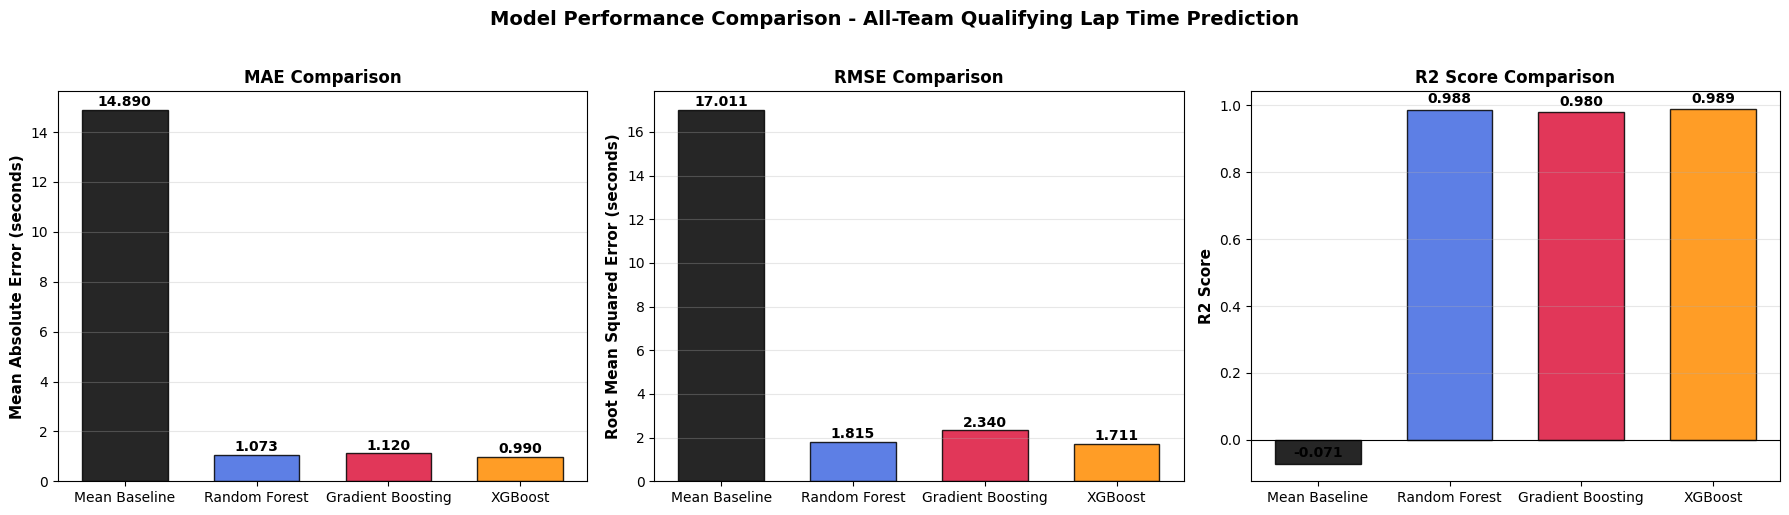

In [18]:
# Model Comparison for qualifying prediction
models = ['Mean Baseline', 'Random Forest', 'Gradient Boosting', 'XGBoost']
mae_scores = [ q_mean_baseline_mae, q_rf_mae, q_gb_mae, q_xgb_mae]
rmse_scores = [ q_mean_baseline_rmse, q_rf_rmse, q_gb_rmse, q_xgb_rmse]
r2_scores = [ q_mean_baseline_r2, q_rf_r2, q_gb_r2, q_xgb_r2]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bar_colors = ['black', 'royalblue', 'crimson', 'darkorange']

# MAE Comparison
axes[0].bar(models, mae_scores, color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[0].set_ylabel('Mean Absolute Error (seconds)', fontsize=11, fontweight='bold')
axes[0].set_title('MAE Comparison', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(mae_scores):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# RMSE Comparison
axes[1].bar(models, rmse_scores, color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[1].set_ylabel('Root Mean Squared Error (seconds)', fontsize=11, fontweight='bold')
axes[1].set_title('RMSE Comparison', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# R2 Comparison
axes[2].bar(models, r2_scores, color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[2].set_ylabel('R2 Score', fontsize=11, fontweight='bold')
axes[2].set_title('R2 Score Comparison', fontsize=12, fontweight='bold')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[2].grid(alpha=0.3, axis='y')
for i, v in enumerate(r2_scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Model Performance Comparison - All-Team Qualifying Lap Time Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
save_figure(fig, f"f1_{year}_{cache_gp}_qualifying_model_comparison.png")

 ##### Residual Diagnostics

 Residual plots show where prediction error stays centered and where it spreads out. A tight concentration around zero suggests the model is stable on representative laps, while heavy tails or skew indicate pace contexts the feature set still struggles to explain.

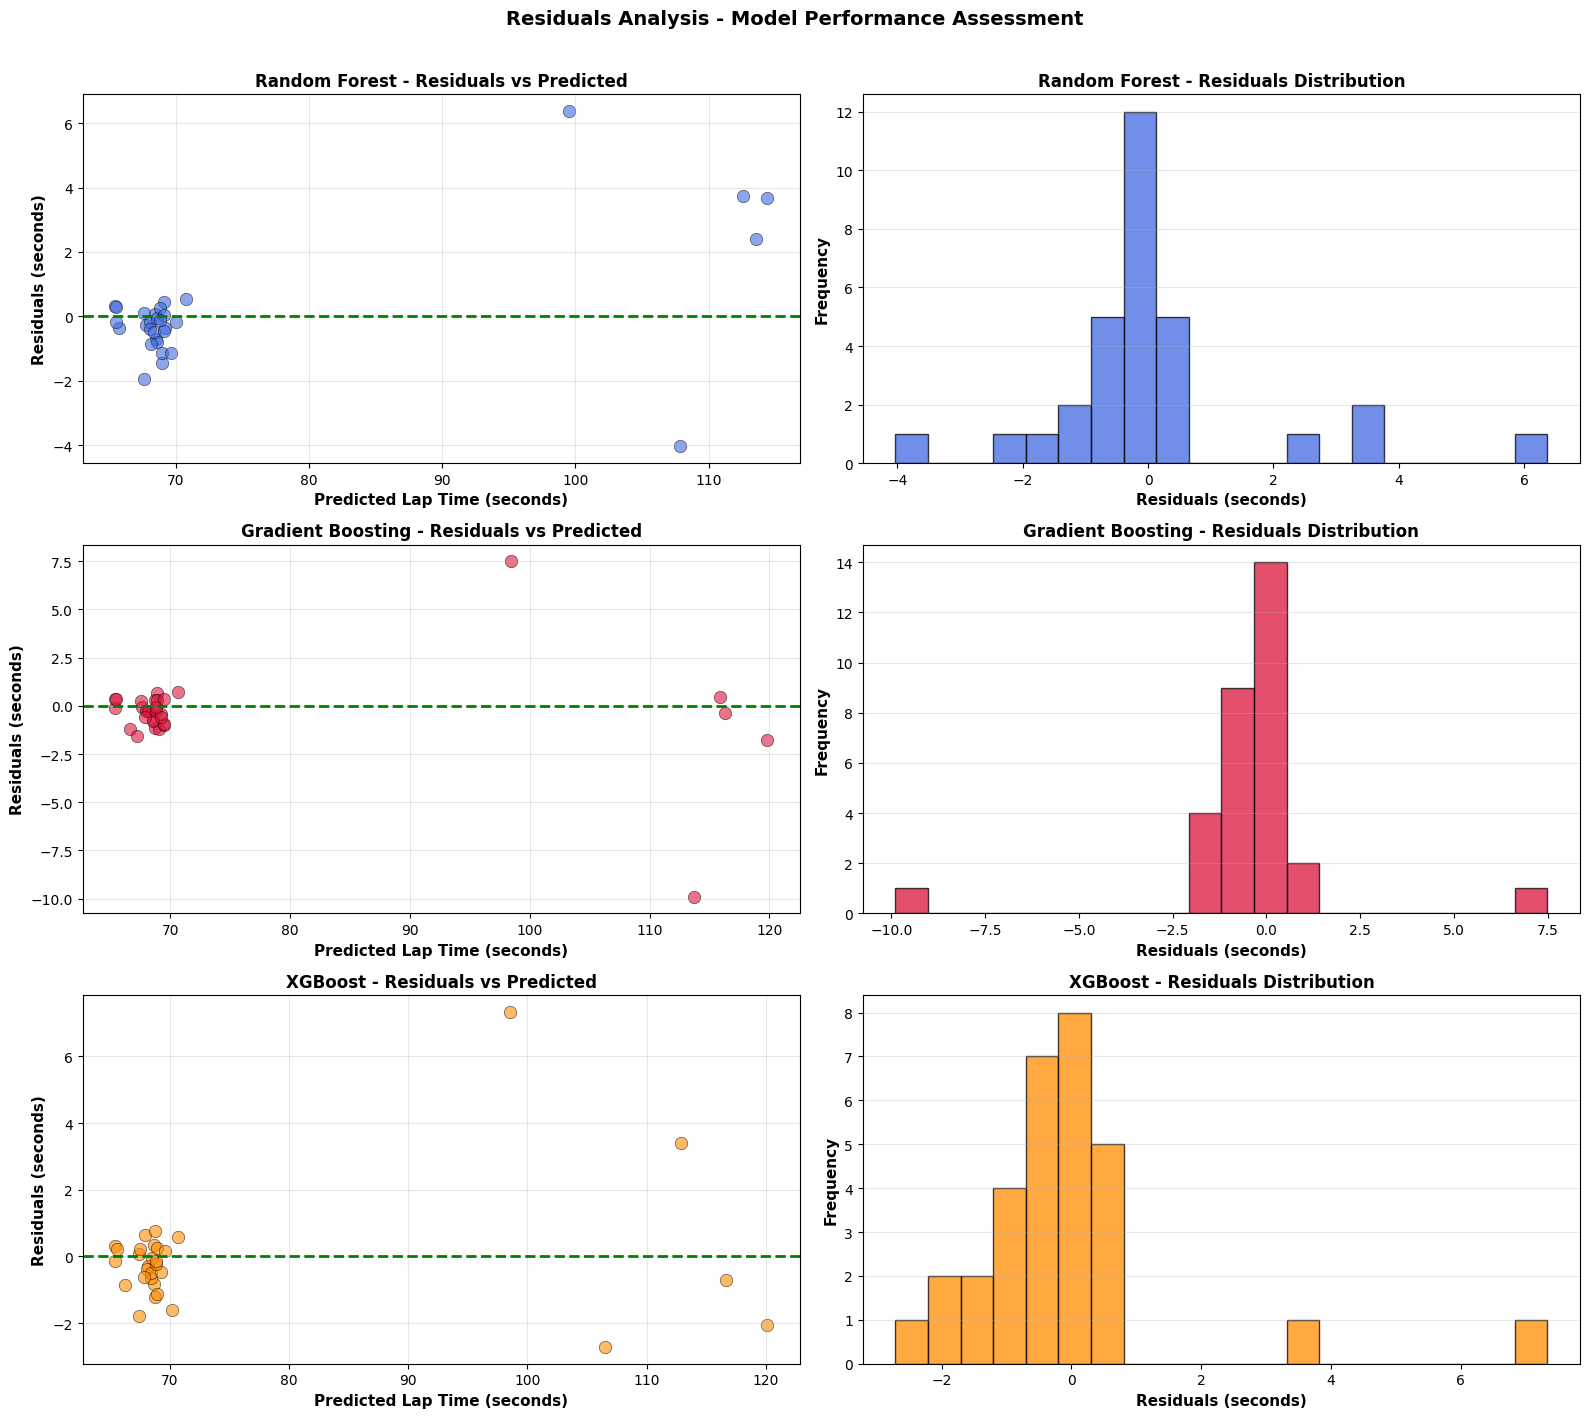

Random Forest - Mean Residuals: 0.1044, Std Dev: 1.8423
Gradient Boosting - Mean Residuals: -0.3913, Std Dev: 2.3455
XGBoost - Mean Residuals: -0.0641, Std Dev: 1.7380


In [19]:
# Residuals Analysis
rf_residuals = q_y_test - q_rf_predictions
gb_residuals = q_y_test - q_gb_predictions
xgb_residuals = q_y_test - q_xgb_predictions

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Random Forest - Residuals vs Predicted
axes[0, 0].scatter(q_rf_predictions, rf_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='royalblue')
axes[0, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Random Forest - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Random Forest - Residuals Distribution
axes[0, 1].hist(rf_residuals, bins=20, alpha=0.75, color='royalblue', edgecolor='black')
axes[0, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Random Forest - Residuals Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='y')

# Gradient Boosting - Residuals vs Predicted
axes[1, 0].scatter(q_gb_predictions, gb_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='crimson')
axes[1, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Gradient Boosting - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Gradient Boosting - Residuals Distribution
axes[1, 1].hist(gb_residuals, bins=20, alpha=0.75, color='crimson', edgecolor='black')
axes[1, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Gradient Boosting - Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')

# XGBoost - Residuals vs Predicted
axes[2, 0].scatter(q_xgb_predictions, xgb_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='darkorange')
axes[2, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[2, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[2, 0].set_title('XGBoost - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[2, 0].grid(alpha=0.3)

# XGBoost - Residuals Distribution
axes[2, 1].hist(xgb_residuals, bins=20, alpha=0.75, color='darkorange', edgecolor='black')
axes[2, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[2, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[2, 1].set_title('XGBoost - Residuals Distribution', fontsize=12, fontweight='bold')
axes[2, 1].grid(alpha=0.3, axis='y')

plt.suptitle('Residuals Analysis - Model Performance Assessment', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Random Forest - Mean Residuals: {rf_residuals.mean():.4f}, Std Dev: {rf_residuals.std():.4f}")
print(f"Gradient Boosting - Mean Residuals: {gb_residuals.mean():.4f}, Std Dev: {gb_residuals.std():.4f}")
print(f"XGBoost - Mean Residuals: {xgb_residuals.mean():.4f}, Std Dev: {xgb_residuals.std():.4f}")

 ##### Actual vs Predicted Fit

 Actual-versus-predicted plots provide a direct visual check on calibration across the observed lap-time range. Points close to the diagonal indicate strong agreement, while systematic deviation or widening spread signals underfit regions, outliers, or missing context.

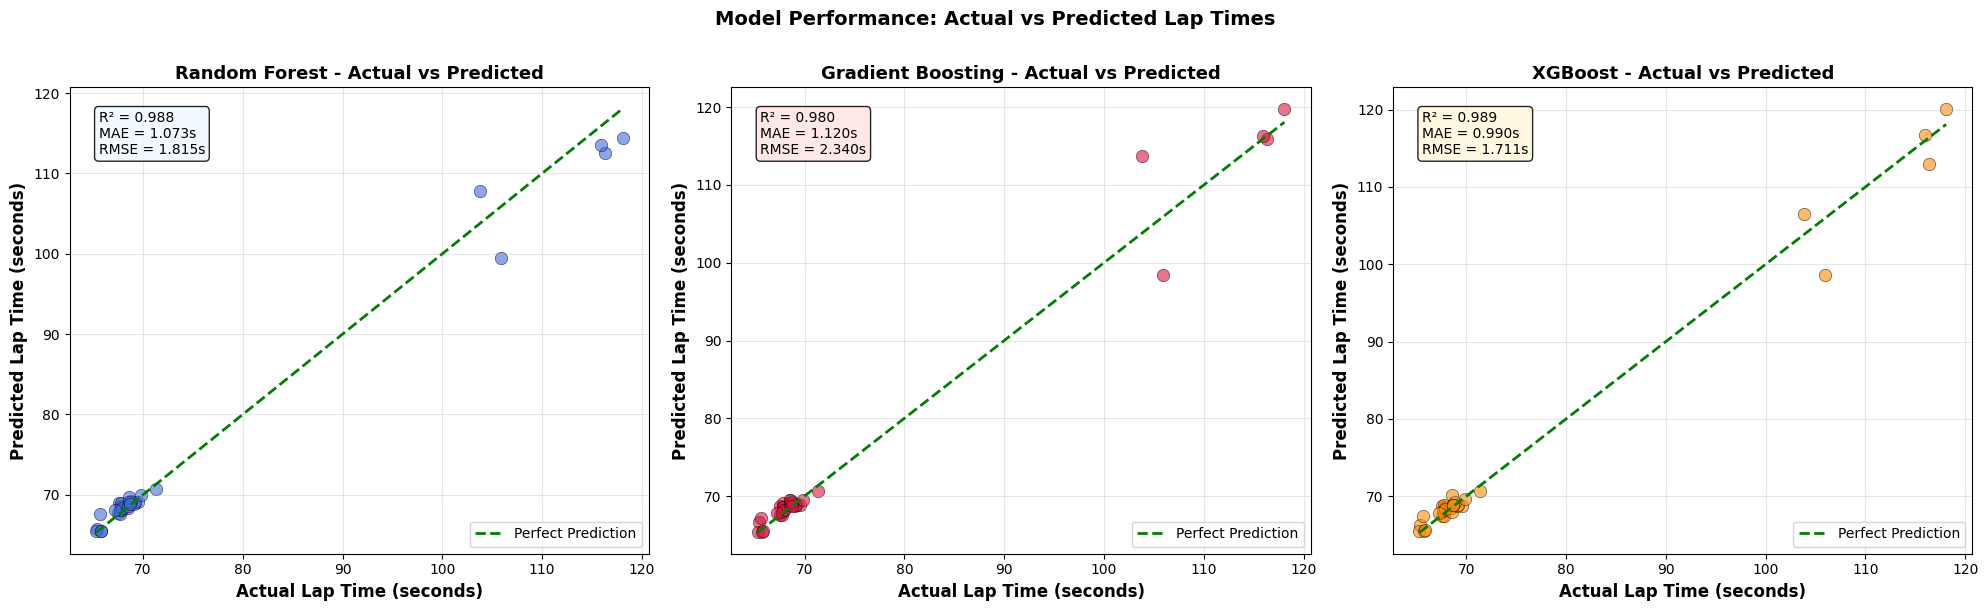

In [20]:
# Actual vs Predicted - Side by side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Random Forest: Actual vs Predicted
axes[0].scatter(q_y_test, q_rf_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='royalblue')
axes[0].plot([q_y_test.min(), q_y_test.max()], [q_y_test.min(), q_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[0].set_title('Random Forest - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].text(0.05, 0.95, f'R² = {q_rf_r2:.3f}\nMAE = {q_rf_mae:.3f}s\nRMSE = {q_rf_rmse:.3f}s',
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='aliceblue', alpha=0.85)
             )

# Gradient Boosting: Actual vs Predicted
axes[1].scatter(q_y_test, q_gb_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='crimson')
axes[1].plot([q_y_test.min(), q_y_test.max()], [q_y_test.min(), q_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_title('Gradient Boosting - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].text(0.05, 0.95, f'R² = {q_gb_r2:.3f}\nMAE = {q_gb_mae:.3f}s\nRMSE = {q_gb_rmse:.3f}s', 
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.85)
             )

# XGBoost: Actual vs Predicted
axes[2].scatter(q_y_test, q_xgb_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='darkorange')
axes[2].plot([q_y_test.min(), q_y_test.max()], [q_y_test.min(), q_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[2].set_title('XGBoost - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)
axes[2].text(0.05, 0.95, f'R² = {q_xgb_r2:.3f}\nMAE = {q_xgb_mae:.3f}s\nRMSE = {q_xgb_rmse:.3f}s', 
             transform=axes[2].transAxes, fontsize=10, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='cornsilk', alpha=0.85)
             )

plt.suptitle('Model Performance: Actual vs Predicted Lap Times', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

 ### Tyre Degradation Model Pipeline

In [21]:
def tyredeg_model_pipeline():
    print("Starting tyre degradation model pipeline")

    # Use all-team data and keep columns needed for modeling
    model_df = practice_df.copy()

    # Reduce extreme outliers that hurt variance-based metrics like R^2
    low_q, high_q = model_df['LapTime'].quantile([0.05, 0.95])
    model_df = model_df[(model_df['LapTime'] >= low_q) & (model_df['LapTime'] <= high_q)].copy()

    # Validate required columns for tyre degradation analysis
    required_filter_cols = ['Compound', 'TyreLife']
    missing_filter_cols = [col for col in required_filter_cols if col not in model_df.columns]
    if missing_filter_cols:
        raise KeyError(f"Missing required filter column(s): {missing_filter_cols}")

    # Include ALL tyre compounds to study degradation patterns across compound types
    valid_compounds = ['SOFT', 'MEDIUM', 'HARD']
    compound_mask = model_df['Compound'].astype(str).str.upper().isin(valid_compounds)
    model_df = model_df[compound_mask].copy()
    print(f"Rows after compound filter (SOFT, MEDIUM, HARD): {len(model_df)}")
    print("Compound distribution:")
    print(model_df['Compound'].value_counts().to_string())

    if 'Session' not in model_df.columns:
        raise KeyError("Missing required column: Session")
    
    print("Session distribution:")
    print(model_df['Session'].value_counts().to_string())

    # Convert model inputs to stable numeric types before feature engineering
    for numeric_col in ['LapNumber', 'TyreLife', 'Stint']:
        if numeric_col in model_df.columns:
            model_df[numeric_col] = pd.to_numeric(model_df[numeric_col], errors='coerce')

    if 'FreshTyre' in model_df.columns:
        model_df['FreshTyre'] = model_df['FreshTyre'].fillna('Unknown').astype(str)

    # Define features and target
    telemetry_candidate_features = ['SpeedST', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'Throttle', 'Brake', 'TrackTemp', 'AirTemp', 'Humidity']
    telemetry_features = [
        col for col in telemetry_candidate_features
        if col in model_df.columns and pd.api.types.is_numeric_dtype(model_df[col])
    ]
    base_numeric_features = list(dict.fromkeys(['LapNumber', 'TyreLife', 'Stint'] + telemetry_features))
    categorical_features = ['Compound', 'Driver', 'Team', 'Session', 'TrackStatus']
    if 'FreshTyre' in model_df.columns:
        categorical_features.append('FreshTyre')

    features = base_numeric_features + categorical_features
    target = 'LapTime'

    # Keep rows where required columns exist and are non-null
    required_cols = base_numeric_features + categorical_features + [target]
    model_df = model_df[required_cols].dropna().copy()

    print(f"TyreLife range: {model_df['TyreLife'].min()} to {model_df['TyreLife'].max()}")

    # Split into features and target using driver-disjoint validation
    X = model_df[base_numeric_features + categorical_features].copy()
    y = model_df[target].copy()

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=324)
    train_idx, test_idx = next(splitter.split(X, y, groups=X['Driver']))
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

    # Build train-only median baselines and target encodings
    train_df = X_train.copy()
    train_df['LapTime'] = y_train.values
    test_df = X_test.copy().reset_index(drop=True)
    X_train = train_df[features].copy()
    X_test = test_df[features].copy()

    preprocessor = ColumnTransformer(
        transformers=[('num', 'passthrough', base_numeric_features),
                      ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
                      ])

    mean_baseline = DummyRegressor(strategy='mean')
    mean_baseline.fit(X_train[base_numeric_features], y_train)
    mean_baseline_predictions = mean_baseline.predict(X_test[base_numeric_features])
    mean_baseline_mae = mean_absolute_error(y_test, mean_baseline_predictions)
    mean_baseline_rmse = np.sqrt(mean_squared_error(y_test, mean_baseline_predictions))
    mean_baseline_r2 = r2_score(y_test, mean_baseline_predictions)

    # Create model pipelines
    rf_model = Pipeline(
        steps=[('preprocessor', preprocessor),
               ('rf_regressor', RandomForestRegressor(n_estimators=420, min_samples_leaf=1,
                                                      max_features='sqrt', random_state=324, n_jobs=-1))
                                                      ])

    gb_model = Pipeline(
        steps=[('preprocessor', preprocessor),
               ('gb_regressor', GradientBoostingRegressor(n_estimators=350, learning_rate=0.04,
                                                          subsample=0.85, random_state=324))
                                                          ])

    xgb_model = Pipeline(
        steps=[('preprocessor', preprocessor),
               ('xgb_regressor', XGBRegressor(n_estimators=600, learning_rate=0.03, max_depth=4,
                                              min_child_weight=3, subsample=0.9, colsample_bytree=0.9,
                                              reg_alpha=0.1, reg_lambda=1.2, random_state=324,
                                              verbosity=0, objective='reg:squarederror', tree_method='hist'))
                                              ])

    # Train model and make predictions
    print("Training Random Forest model")
    rf_model.fit(X_train, y_train)
    rf_predictions = rf_model.predict(X_test)

    print("Training Gradient Boosting model")
    gb_model.fit(X_train, y_train)
    gb_predictions = gb_model.predict(X_test)

    print("Training XGBoost model")
    xgb_model.fit(X_train, y_train)
    xgb_predictions = xgb_model.predict(X_test)

    # Calculate model metrics
    rf_mae = mean_absolute_error(y_test, rf_predictions)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
    rf_r2 = r2_score(y_test, rf_predictions)

    gb_mae = mean_absolute_error(y_test, gb_predictions)
    gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
    gb_r2 = r2_score(y_test, gb_predictions)

    xgb_mae = mean_absolute_error(y_test, xgb_predictions)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
    xgb_r2 = r2_score(y_test, xgb_predictions)

    # Driver-level diagnostics: keep MAE columns for reference, but select best model by fastest predicted lap.
    driver_eval_df = X_test[['Driver', 'Team', 'Session']].copy().reset_index(drop=True)
    driver_eval_df['ActualLapTime'] = y_test.reset_index(drop=True)
    driver_eval_df['RF_Pred'] = rf_predictions
    driver_eval_df['GB_Pred'] = gb_predictions
    driver_eval_df['XGB_Pred'] = xgb_predictions
    driver_eval_df['RF_AbsErr'] = (driver_eval_df['ActualLapTime'] - driver_eval_df['RF_Pred']).abs()
    driver_eval_df['GB_AbsErr'] = (driver_eval_df['ActualLapTime'] - driver_eval_df['GB_Pred']).abs()
    driver_eval_df['XGB_AbsErr'] = (driver_eval_df['ActualLapTime'] - driver_eval_df['XGB_Pred']).abs()

    t_driver_mae = (driver_eval_df.groupby('Driver', as_index=False)[['RF_AbsErr', 'GB_AbsErr', 'XGB_AbsErr', 'RF_Pred', 'GB_Pred', 'XGB_Pred']].mean()
                    .rename(columns={'RF_AbsErr': 'RF_MAE',
                                     'GB_AbsErr': 'GB_MAE',
                                     'XGB_AbsErr': 'XGB_MAE',
                                     'RF_Pred': 'RF_PredMean',
                                     'GB_Pred': 'GB_PredMean',
                                     'XGB_Pred': 'XGB_PredMean'
                                     }))

    t_driver_mae['BestModel'] = t_driver_mae[['RF_PredMean', 'GB_PredMean', 'XGB_PredMean']].idxmin(axis=1).map({
        'RF_PredMean': 'Random Forest Regression',
        'GB_PredMean': 'Gradient Boosting Regression',
        'XGB_PredMean': 'XGBoost Regression'
    })
    t_driver_mae['BestPredLapTime'] = t_driver_mae[['RF_PredMean', 'GB_PredMean', 'XGB_PredMean']].min(axis=1)
    t_driver_mae = t_driver_mae.sort_values('BestPredLapTime').reset_index(drop=True)

    print("Model training completed")

    return {
        't_model_df': model_df,
        't_features': features,
        't_X_train': X_train,
        't_X_test': X_test,
        't_y_train': y_train,
        't_y_test': y_test,
        't_mean_baseline_predictions': mean_baseline_predictions,
        't_mean_baseline_mae': mean_baseline_mae,
        't_mean_baseline_rmse': mean_baseline_rmse,
        't_mean_baseline_r2': mean_baseline_r2,
        't_rf_model': rf_model,
        't_rf_predictions': rf_predictions,
        't_rf_mae': rf_mae,
        't_rf_rmse': rf_rmse,
        't_rf_r2': rf_r2,
        't_gb_model': gb_model,
        't_gb_predictions': gb_predictions,
        't_gb_mae': gb_mae,
        't_gb_rmse': gb_rmse,
        't_gb_r2': gb_r2,
        't_xgb_model': xgb_model,
        't_xgb_predictions': xgb_predictions,
        't_xgb_mae': xgb_mae,
        't_xgb_rmse': xgb_rmse,
        't_xgb_r2': xgb_r2,
        't_driver_eval_df': driver_eval_df,
        't_driver_mae': t_driver_mae
    }

In [22]:
# Run the model pipeline
model_results = tyredeg_model_pipeline()

# Extract results
t_model_df = model_results['t_model_df']
t_features = model_results['t_features']
t_X_train = model_results['t_X_train']
t_X_test = model_results['t_X_test']
t_y_train = model_results['t_y_train']
t_y_test = model_results['t_y_test']
t_mean_baseline_predictions = model_results['t_mean_baseline_predictions']
t_mean_baseline_mae = model_results['t_mean_baseline_mae']
t_mean_baseline_rmse = model_results['t_mean_baseline_rmse']
t_mean_baseline_r2 = model_results['t_mean_baseline_r2']
t_rf_model = model_results['t_rf_model']
t_rf_predictions = model_results['t_rf_predictions']
t_rf_mae = model_results['t_rf_mae']
t_rf_rmse = model_results['t_rf_rmse']
t_rf_r2 = model_results['t_rf_r2']
t_gb_model = model_results['t_gb_model']
t_gb_predictions = model_results['t_gb_predictions']
t_gb_mae = model_results['t_gb_mae']
t_gb_rmse = model_results['t_gb_rmse']
t_gb_r2 = model_results['t_gb_r2']
t_xgb_model = model_results['t_xgb_model']
t_xgb_predictions = model_results['t_xgb_predictions']
t_xgb_mae = model_results['t_xgb_mae']
t_xgb_rmse = model_results['t_xgb_rmse']
t_xgb_r2 = model_results['t_xgb_r2']
t_driver_mae = model_results['t_driver_mae']

Starting tyre degradation model pipeline
Rows after compound filter (SOFT, MEDIUM, HARD): 757
Compound distribution:
Compound
MEDIUM    345
SOFT      272
HARD      140
Session distribution:
Session
FP2    351
FP1    215
FP3    191
TyreLife range: 2.0 to 25.0
Training Random Forest model
Training Gradient Boosting model
Training XGBoost model
Model training completed


In [23]:
# Compare the performance of all trained models from the pipeline
perform_df = pd.DataFrame({
    'Model': ['Mean Baseline', 'Random Forest Regression', 'Gradient Boosting Regression' , 'XGBoost Regression'],
    'Mean Absolute Error (MAE)': [t_mean_baseline_mae, t_rf_mae, t_gb_mae, t_xgb_mae],
    'Root Absolute Error (RMSE)': [t_mean_baseline_rmse, t_rf_rmse, t_gb_rmse, t_xgb_rmse],
    'R² Score': [t_mean_baseline_r2, t_rf_r2, t_gb_r2, t_xgb_r2]
})
perform_df['Mean Absolute Error (MAE)'] = perform_df['Mean Absolute Error (MAE)'].apply(lambda x: f"{x:,.3f} sec")
perform_df['Root Absolute Error (RMSE)'] = perform_df['Root Absolute Error (RMSE)'].apply(lambda x: f"{x:,.3f} sec")
perform_df['R² Score'] = perform_df['R² Score'].apply(lambda x: f"{x:.3f}")

print("Tyre Degradation Pipeline Model Comparison:")
print(perform_df.to_string(index=False))

# Determine the best tyre degradation model.
if t_rf_r2 > t_gb_r2 and t_rf_r2 > t_xgb_r2:
    best_model = 'Random Forest Regression'
    print(f"\nBest performing model for predicting tyre degradation: {best_model}")
elif t_rf_r2 < t_gb_r2 and t_gb_r2 > t_xgb_r2:
    best_model = 'Gradient Boosting Regression'
    print(f"\nBest performing model for predicting tyre degradation: {best_model}")
elif t_xgb_r2 > t_rf_r2 and t_xgb_r2 > t_gb_r2:
    best_model = 'XGBoost Regression'
    print(f"\nBest performing model for predicting tyre degradation: {best_model}")
else:
    print("\nModels have the same R² score. No clear best model.")

# Driver-level model selection now uses the fastest predicted lap across the 3 models.
print("\nDriver-level model picked by fastest predicted lap (lower seconds is better):")
print(t_driver_mae[['Driver', 'RF_MAE', 'GB_MAE', 'XGB_MAE', 'RF_PredMean', 'GB_PredMean', 'XGB_PredMean', 'BestModel', 'BestPredLapTime']].sort_values('BestPredLapTime')
      .to_string(index=False)
      )

Tyre Degradation Pipeline Model Comparison:
                       Model Mean Absolute Error (MAE) Root Absolute Error (RMSE) R² Score
               Mean Baseline                11.783 sec                 13.581 sec   -0.079
    Random Forest Regression                 2.249 sec                  3.947 sec    0.909
Gradient Boosting Regression                 2.051 sec                  3.810 sec    0.915
          XGBoost Regression                 1.977 sec                  3.546 sec    0.926

Best performing model for predicting tyre degradation: XGBoost Regression

Driver-level model picked by fastest predicted lap (lower seconds is better):
Driver   RF_MAE   GB_MAE  XGB_MAE  RF_PredMean  GB_PredMean  XGB_PredMean                    BestModel  BestPredLapTime
   COL 1.087840 0.442059 0.514721    75.122279    74.315587     74.166939           XGBoost Regression        74.166939
   ANT 1.886878 1.767629 2.103297    75.895891    75.429478     75.721718 Gradient Boosting Regression     

 #### Tyre Degradation Model Performance Visualizations

 The performance visuals complement the printed metric table by showing error size, residual structure, and actual-versus-predicted alignment. Together they make it easier to judge whether a model is just numerically better or actually more reliable across the pace range.

 ##### Metric Comparison

 The comparison charts summarize average error, sensitivity to larger misses, and explained variance. The printed table above includes Random Forest, Gradient Boosting, and XGBoost; the plots in this section focus on the main diagnostic comparisons used in the notebook output.



 Lower MAE and RMSE, along with higher R2, indicate stronger predictive performance. The baseline mean predictor is included to confirm that the models are extracting genuine structure from the lap data.

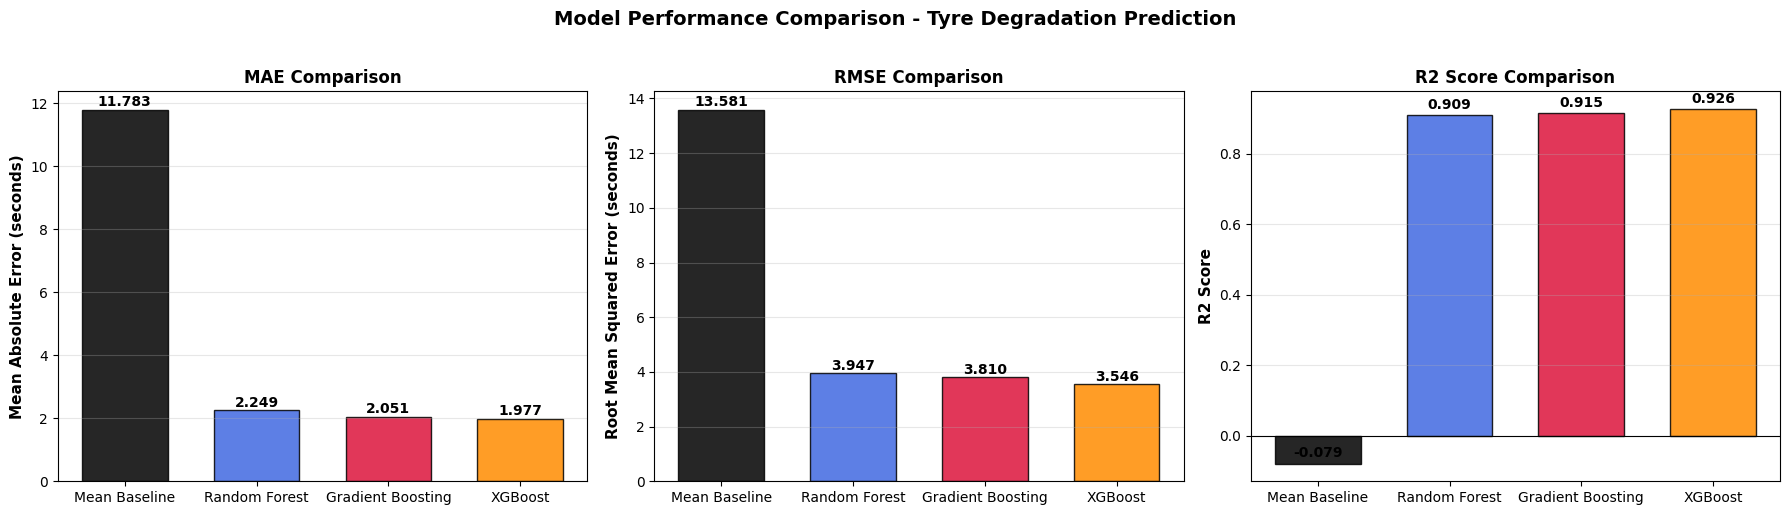

In [24]:
# Model Comparison for tyre degradation prediction
models = ['Mean Baseline', 'Random Forest', 'Gradient Boosting', 'XGBoost']
mae_scores = [t_mean_baseline_mae, t_rf_mae, t_gb_mae, t_xgb_mae]
rmse_scores = [t_mean_baseline_rmse, t_rf_rmse, t_gb_rmse, t_xgb_rmse]
r2_scores = [t_mean_baseline_r2, t_rf_r2, t_gb_r2, t_xgb_r2]

# Compare all trained models directly; keep baseline only for R² context
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bar_colors = ['black', 'royalblue', 'crimson', 'darkorange']

# MAE Comparison
axes[0].bar(models, mae_scores, color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[0].set_ylabel('Mean Absolute Error (seconds)', fontsize=11, fontweight='bold')
axes[0].set_title('MAE Comparison', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(mae_scores):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# RMSE Comparison
axes[1].bar(models, rmse_scores, color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[1].set_ylabel('Root Mean Squared Error (seconds)', fontsize=11, fontweight='bold')
axes[1].set_title('RMSE Comparison', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# R2 Comparison (includes baseline)
colors_r2 = ['black', 'royalblue', 'crimson', 'darkorange', 'lightgray']
axes[2].bar(models, r2_scores, color=colors_r2, edgecolor='black', alpha=0.85, width=0.65)
axes[2].set_ylabel('R2 Score', fontsize=11, fontweight='bold')
axes[2].set_title('R2 Score Comparison', fontsize=12, fontweight='bold')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[2].grid(alpha=0.3, axis='y')
for i, v in enumerate(r2_scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Model Performance Comparison - Tyre Degradation Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
save_figure(fig, f"f1_{year}_{cache_gp}_tyre_degradation_model_comparison.png")

 ##### Residual Diagnostics

 Residual plots show where prediction error stays centered and where it spreads out. A tight concentration around zero suggests the model is stable on representative laps, while heavy tails or skew indicate pace contexts the feature set still struggles to explain.

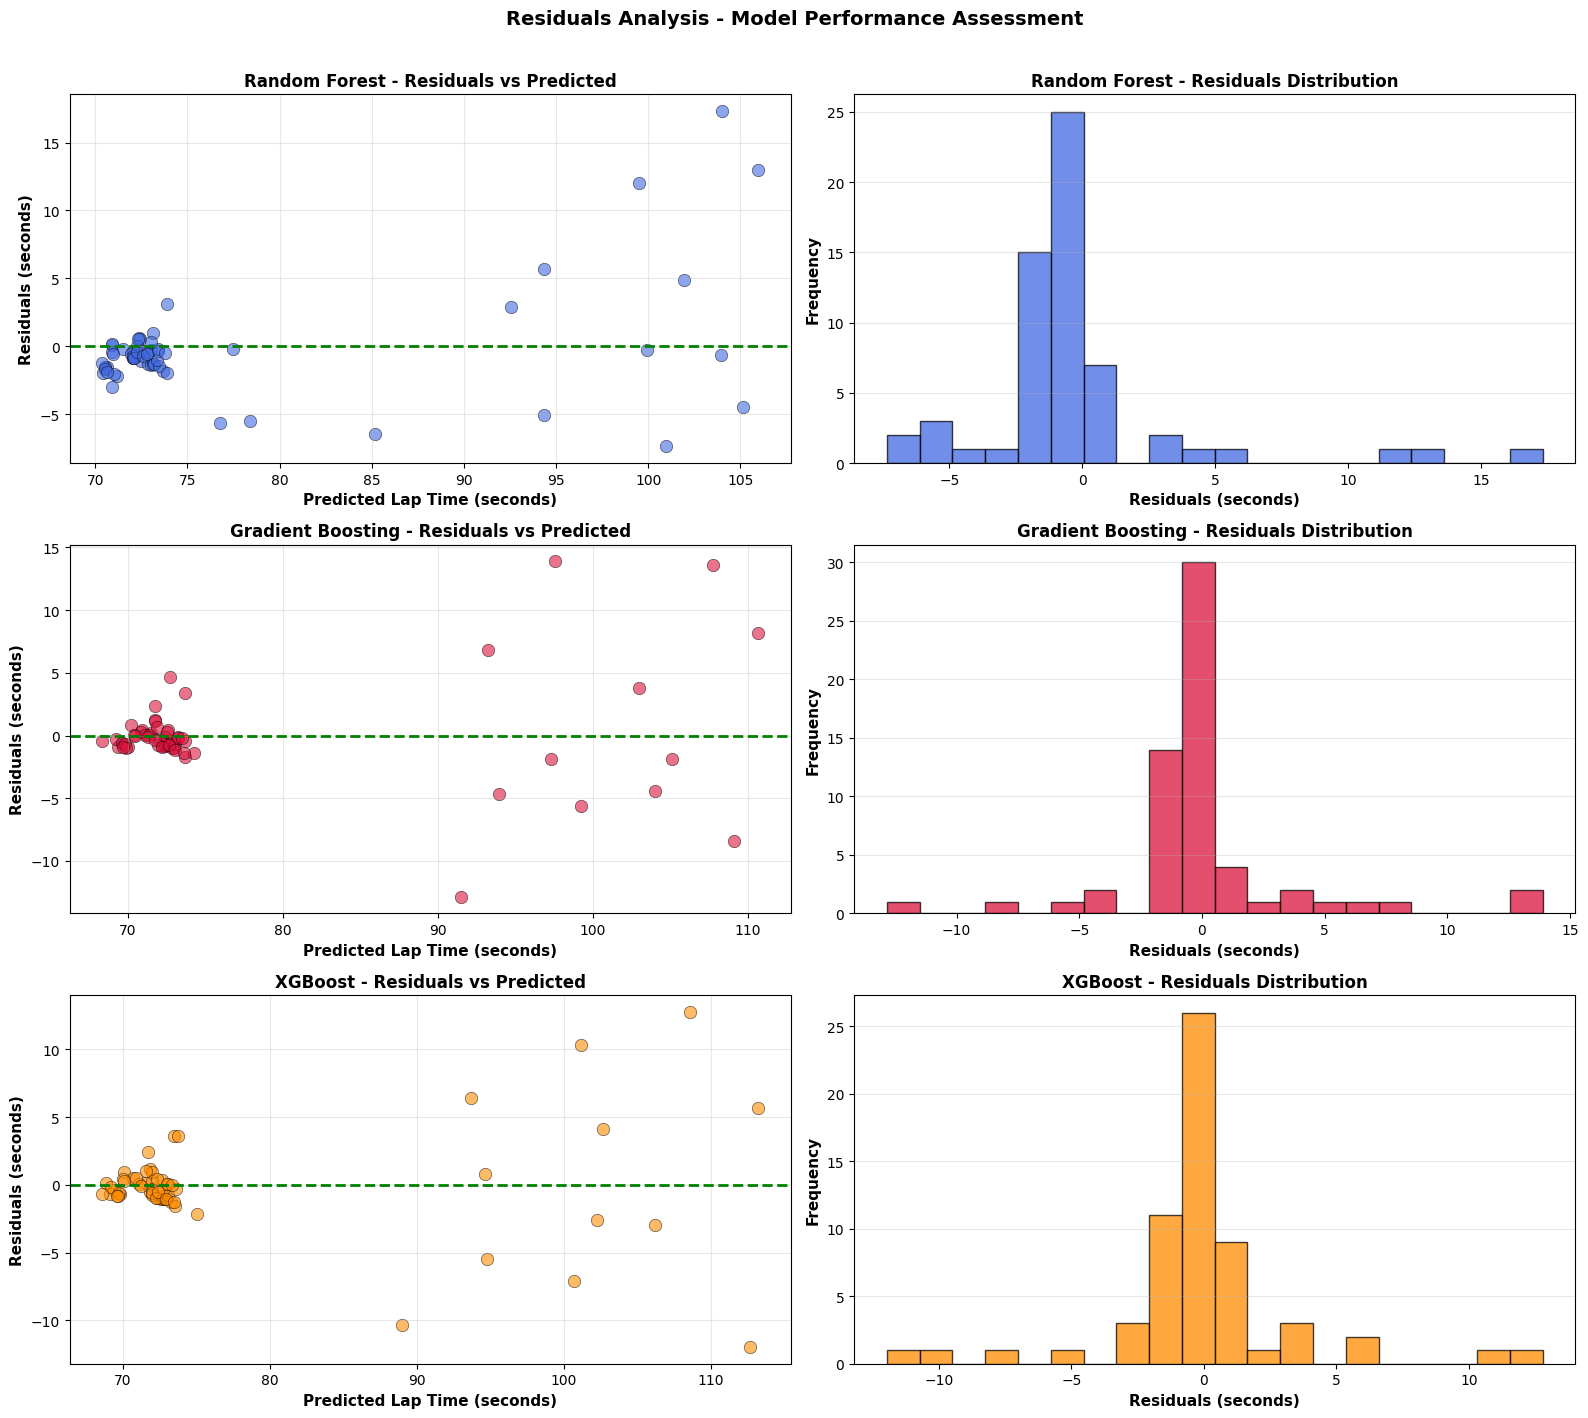

Random Forest - Mean Residuals: -0.2079, Std Dev: 3.9743
Gradient Boosting - Mean Residuals: -0.0132, Std Dev: 3.8412
XGBoost - Mean Residuals: -0.1020, Std Dev: 3.5740


In [25]:
# Residuals Analysis
t_rf_residuals = t_y_test - t_rf_predictions
t_gb_residuals = t_y_test - t_gb_predictions
t_xgb_residuals = t_y_test - t_xgb_predictions

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Random Forest - Residuals vs Predicted
axes[0, 0].scatter(t_rf_predictions, t_rf_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='royalblue')
axes[0, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Random Forest - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Random Forest - Residuals Distribution
axes[0, 1].hist(t_rf_residuals, bins=20, alpha=0.75, color='royalblue', edgecolor='black')
axes[0, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Random Forest - Residuals Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='y')

# Gradient Boosting - Residuals vs Predicted
axes[1, 0].scatter(t_gb_predictions, t_gb_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='crimson')
axes[1, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Gradient Boosting - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Gradient Boosting - Residuals Distribution
axes[1, 1].hist(t_gb_residuals, bins=20, alpha=0.75, color='crimson', edgecolor='black')
axes[1, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Gradient Boosting - Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')

# XGBoost - Residuals vs Predicted
axes[2, 0].scatter(t_xgb_predictions, t_xgb_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='darkorange')
axes[2, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[2, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[2, 0].set_title('XGBoost - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[2, 0].grid(alpha=0.3)

# XGBoost - Residuals Distribution
axes[2, 1].hist(t_xgb_residuals, bins=20, alpha=0.75, color='darkorange', edgecolor='black')
axes[2, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[2, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[2, 1].set_title('XGBoost - Residuals Distribution', fontsize=12, fontweight='bold')
axes[2, 1].grid(alpha=0.3, axis='y')

plt.suptitle('Residuals Analysis - Model Performance Assessment', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Random Forest - Mean Residuals: {t_rf_residuals.mean():.4f}, Std Dev: {t_rf_residuals.std():.4f}")
print(f"Gradient Boosting - Mean Residuals: {t_gb_residuals.mean():.4f}, Std Dev: {t_gb_residuals.std():.4f}")
print(f"XGBoost - Mean Residuals: {t_xgb_residuals.mean():.4f}, Std Dev: {t_xgb_residuals.std():.4f}")

 ##### Actual vs Predicted Fit

 Actual-versus-predicted plots provide a direct visual check on calibration across the observed lap-time range. Points close to the diagonal indicate strong agreement, while systematic deviation or widening spread signals underfit regions, outliers, or missing context.

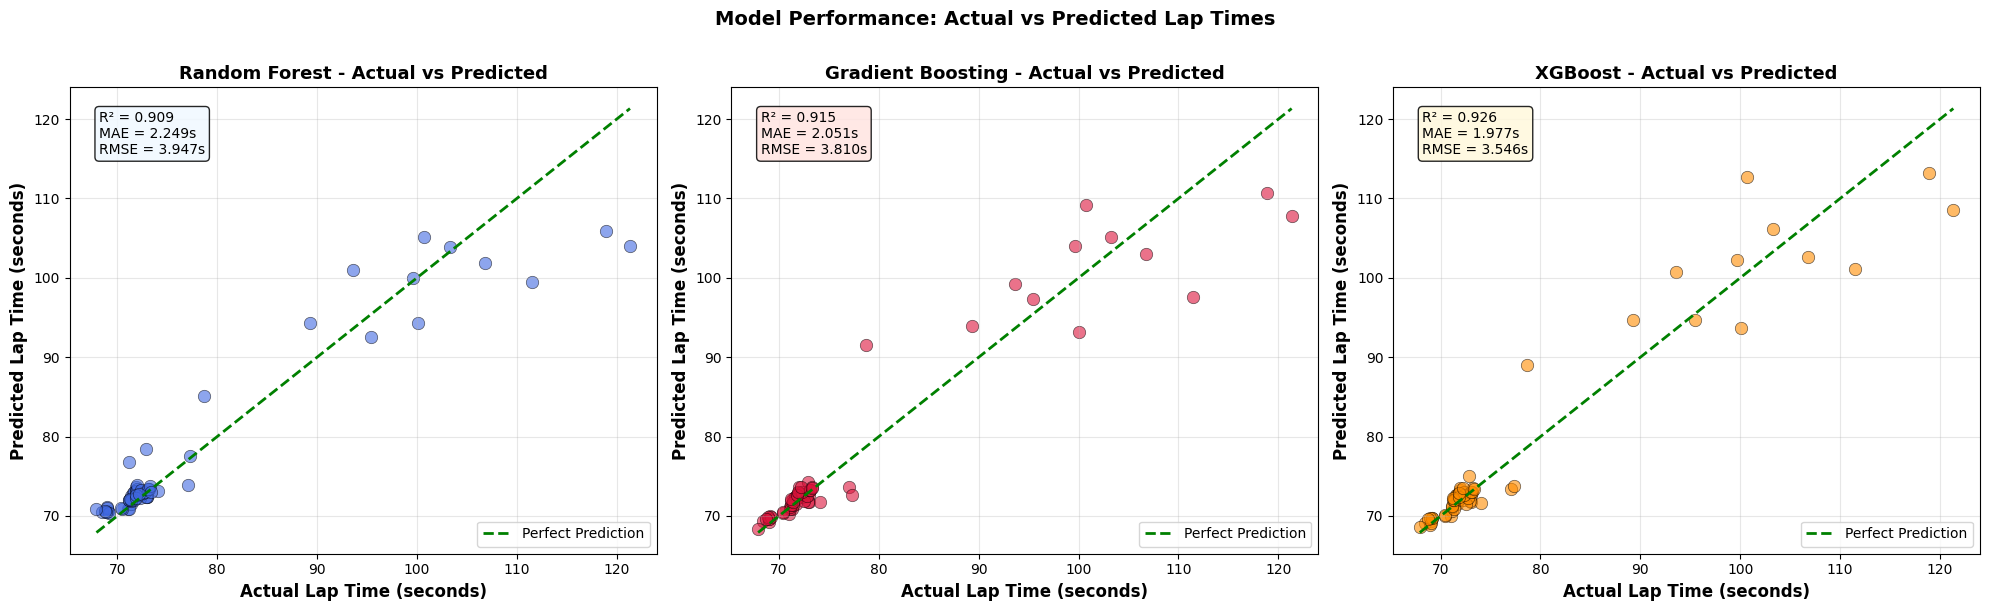

In [26]:
# Actual vs Predicted - Side by side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Random Forest: Actual vs Predicted
axes[0].scatter(t_y_test, t_rf_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='royalblue')
axes[0].plot([t_y_test.min(), t_y_test.max()], [t_y_test.min(), t_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[0].set_title('Random Forest - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].text(0.05, 0.95, f'R² = {t_rf_r2:.3f}\nMAE = {t_rf_mae:.3f}s\nRMSE = {t_rf_rmse:.3f}s', 
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='aliceblue', alpha=0.85)
             )

# Gradient Boosting: Actual vs Predicted
axes[1].scatter(t_y_test, t_gb_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='crimson')
axes[1].plot([t_y_test.min(), t_y_test.max()], [t_y_test.min(), t_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_title('Gradient Boosting - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].text(0.05, 0.95, f'R² = {t_gb_r2:.3f}\nMAE = {t_gb_mae:.3f}s\nRMSE = {t_gb_rmse:.3f}s',
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.85)
             )

# XGBoost: Actual vs Predicted
axes[2].scatter(t_y_test, t_xgb_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='darkorange')
axes[2].plot([t_y_test.min(), t_y_test.max()], [t_y_test.min(), t_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[2].set_title('XGBoost - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)
axes[2].text(0.05, 0.95, f'R² = {t_xgb_r2:.3f}\nMAE = {t_xgb_mae:.3f}s\nRMSE = {t_xgb_rmse:.3f}s',
             transform=axes[2].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='cornsilk', alpha=0.85)
             )

plt.suptitle('Model Performance: Actual vs Predicted Lap Times', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

 ## Qualifying Pace Projection

 This scenario section uses each driver's personalized best validation model to estimate how qualifying-style lap time changes as tyre life increases under controlled assumptions.



 Treat the output as a sensitivity study rather than an exact forecast. It is most useful for comparing relative driver and team behavior under the same modeled conditions.

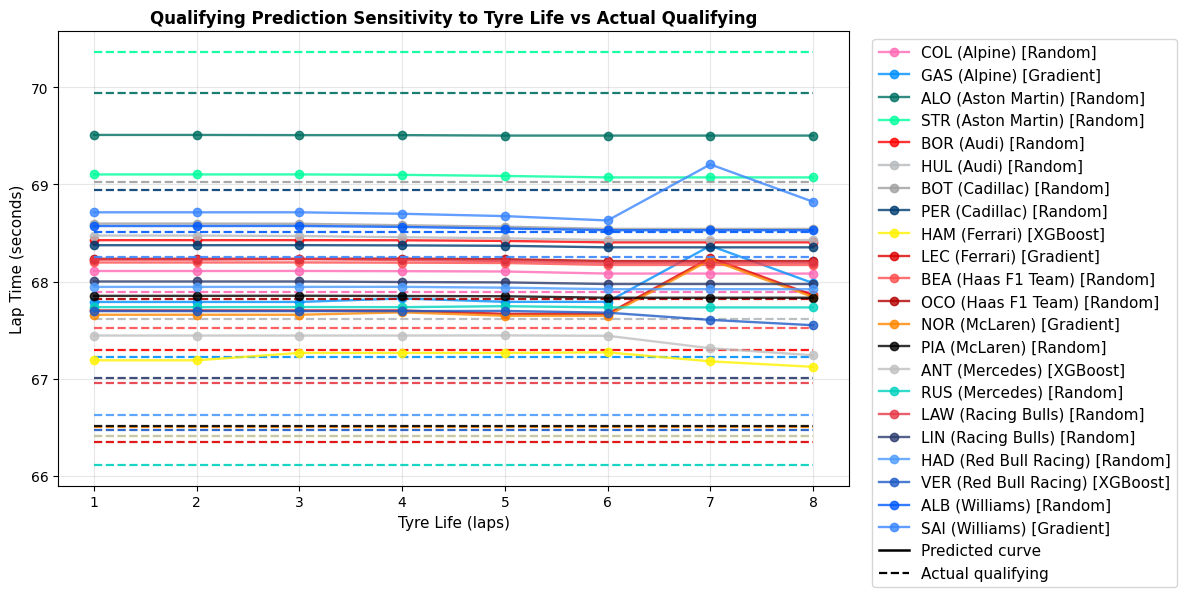

Best predicted qualifying lap by driver:
   Driver             Team  TyreLife  PredictedLapTimeSec PredictedLapTime  LapTimeSec ActualLapTime                     BestModel
0     HAM          Ferrari         8            67.122841         1:07.123      66.408      1:06.408            XGBoost Regression
1     ANT         Mercedes         8            67.241875         1:07.242      66.414      1:06.414            XGBoost Regression
2     VER  Red Bull Racing         8            67.551170         1:07.551      66.475      1:06.475            XGBoost Regression
3     NOR          McLaren         5            67.648889         1:07.649      66.502      1:06.502  Gradient Boosting Regression
4     LEC          Ferrari         5            67.668036         1:07.668      66.349      1:06.349  Gradient Boosting Regression
5     RUS         Mercedes         6            67.734475         1:07.734      66.113      1:06.113      Random Forest Regression
6     GAS           Alpine         1      

In [27]:
# Format lap time in minutes:seconds.milliseconds
def format_lap_time(seconds: float) -> str:
    mins = int(seconds // 60)
    secs = seconds - mins * 60
    return f"{mins}:{secs:06.3f}"

benchmark_practice_df = practice_df.copy()
required_columns = ['Compound', 'FreshTyre', 'LapTime']
missing_columns = [col for col in required_columns if col not in benchmark_practice_df.columns]
if missing_columns:
    raise KeyError(f"Missing required column(s) for benchmark prediction: {missing_columns}")

benchmark_mask = (
    benchmark_practice_df['Compound'].astype(str).str.upper().eq('SOFT')
    & benchmark_practice_df['FreshTyre'].astype(str).eq('True')
    & benchmark_practice_df['LapTime'].notna()
 )
benchmark_practice_df = benchmark_practice_df.loc[benchmark_mask].copy()

if benchmark_practice_df.empty:
    raise ValueError("No current practice laps remain after the SOFT fresh-tyre filter.")

# Use the fastest fresh-soft practice lap per driver as the benchmark input row.
driver_profile = (
    benchmark_practice_df.sort_values(['Driver', 'LapTime'])
    .groupby('Driver', as_index=False)
    .first()
 )

if driver_profile.empty:
    raise ValueError("No driver benchmark rows could be built from the fresh-SOFT practice subset.")

# Load the actual qualifying lap times for the same driver set so the plot can show predicted vs actual.
qualifying_csv_path = globals().get('qualifying_csv_cleaned', 'f1_2025_saudi_arabian_gp_qualifying_cleaned_laps.csv')
qualifying_source_df = globals().get('qualifying_df')
if qualifying_source_df is None:
    qualifying_source_df = pd.read_csv(qualifying_csv_path)

qualifying_laps = qualifying_source_df.copy()
qualifying_laps = qualifying_laps[qualifying_laps['Driver'].isin(driver_profile['Driver'])].copy()
qualifying_laps = qualifying_laps[qualifying_laps['LapTime'].notna()].copy()

if not pd.api.types.is_numeric_dtype(qualifying_laps['LapTime']):
    qualifying_laps['LapTimeSec'] = pd.to_timedelta(qualifying_laps['LapTime'], errors='coerce').dt.total_seconds()
else:
    qualifying_laps['LapTimeSec'] = pd.to_numeric(qualifying_laps['LapTime'], errors='coerce')

actual_qualifying_df = (qualifying_laps.dropna(subset=['LapTimeSec']).sort_values('LapTimeSec')
                        .groupby('Driver', as_index=False).first()[['Driver', 'LapTimeSec']]
                        )

actual_qualifying_df['ActualLapTime'] = actual_qualifying_df['LapTimeSec'].apply(format_lap_time)
actual_qualifying_times = dict(zip(actual_qualifying_df['Driver'], actual_qualifying_df['LapTimeSec']))

model_lookup = {
    'Random Forest Regression': q_rf_model,
    'Gradient Boosting Regression': q_gb_model,
    'XGBoost Regression': q_xgb_model
}

if 'TrackStatus' in benchmark_practice_df.columns and benchmark_practice_df['TrackStatus'].notna().any():
    default_track_status = benchmark_practice_df['TrackStatus'].mode().iloc[0]
elif 'TrackStatus' in practice_df.columns and practice_df['TrackStatus'].notna().any():
    default_track_status = practice_df['TrackStatus'].mode().iloc[0]
else:
    default_track_status = 1

tyre_life_range = list(range(1, 9))
sensitivity_rows = []

for _, row in driver_profile.iterrows():
    for tyre_life in tyre_life_range:
        sensitivity_rows.append({
            'LapNumber': int(round(float(row['LapNumber']))) if pd.notna(row.get('LapNumber')) else 0,
            'TyreLife': tyre_life,
            'Stint': int(round(float(row['Stint']))) if pd.notna(row.get('Stint')) else 0,
            'SpeedFL': float(row['SpeedFL']) if pd.notna(row.get('SpeedFL')) else 0.0,
            'SpeedST': float(row['SpeedST']) if pd.notna(row.get('SpeedST')) else 0.0,
            'TrackStatus': row['TrackStatus'] if pd.notna(row.get('TrackStatus')) else default_track_status,
            'Compound': 'SOFT',
            'Driver': row['Driver'],
            'Team': row['Team'],
            'Session': 'Q'
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)

def get_numeric_default(column_name: str) -> float:
    source_df = benchmark_practice_df if column_name in benchmark_practice_df.columns else practice_df
    if column_name in source_df.columns and pd.api.types.is_numeric_dtype(source_df[column_name]):
        series = pd.to_numeric(source_df[column_name], errors='coerce')
        if series.notna().any():
            return float(series.median())
    return 0.0

def get_categorical_default(column_name: str) -> str:
    source_df = benchmark_practice_df if column_name in benchmark_practice_df.columns else practice_df
    if column_name in source_df.columns:
        mode_vals = source_df[column_name].dropna().mode()
        if len(mode_vals) > 0:
            return str(mode_vals.iloc[0])
    defaults = {'Compound': 'SOFT', 'Driver': 'Unknown', 'Team': 'Unknown', 'Session': 'Q', 'FreshTyre': 'True'}
    return defaults.get(column_name, 'Unknown')

required_prediction_features = list(q_features)
for column_name in required_prediction_features:
    if column_name in sensitivity_df.columns:
        continue
    if column_name in benchmark_practice_df.columns and pd.api.types.is_numeric_dtype(benchmark_practice_df[column_name]):
        sensitivity_df[column_name] = get_numeric_default(column_name)
    elif column_name in benchmark_practice_df.columns:
        sensitivity_df[column_name] = get_categorical_default(column_name)
    elif column_name in practice_df.columns and pd.api.types.is_numeric_dtype(practice_df[column_name]):
        sensitivity_df[column_name] = get_numeric_default(column_name)
    elif column_name in practice_df.columns:
        sensitivity_df[column_name] = get_categorical_default(column_name)
    else:
        sensitivity_df[column_name] = get_categorical_default(column_name) if column_name in ['Compound', 'Driver', 'Team', 'Session'] else 0.0

driver_best_model = {}
driver_prediction_rows = []

for _, driver_row in driver_profile.iterrows():
    driver = driver_row['Driver']
    driver_rows = sensitivity_df[(sensitivity_df['Driver'] == driver) & (sensitivity_df['TyreLife'] == 1)]
    if driver_rows.empty:
        continue

    model_input = driver_rows.head(1).reindex(columns=required_prediction_features)

    candidate_predictions = {
        model_name: float(model.predict(model_input)[0])
        for model_name, model in model_lookup.items()
    }
    best_name = min(candidate_predictions, key=candidate_predictions.get)
    driver_best_model[driver] = best_name
    driver_prediction_rows.append({
        'Driver': driver,
        'BenchmarkPracticeLapTimeSec': float(driver_row['LapTime']) if pd.notna(driver_row.get('LapTime')) else np.nan,
        'BestModel': best_name,
        'BestPredLapTime': candidate_predictions[best_name]
    })

if not driver_best_model:
    raise RuntimeError("No drivers could be assigned a benchmark model. Check the fresh SOFT practice subset and feature preparation.")

def predict_benchmark_row(row: pd.Series) -> float:
    best_name = driver_best_model[row['Driver']]
    model_input = pd.DataFrame([row]).reindex(columns=required_prediction_features)
    return float(model_lookup[best_name].predict(model_input)[0])

sensitivity_df = sensitivity_df[sensitivity_df['Driver'].isin(driver_best_model.keys())].copy()
sensitivity_df['PredictedLapTimeSec'] = sensitivity_df.apply(predict_benchmark_row, axis=1)
sensitivity_df['PredictedLapTime'] = sensitivity_df['PredictedLapTimeSec'].apply(format_lap_time)

fig, ax = plt.subplots(figsize=(12, 6))
plot_driver_profile = driver_profile[driver_profile['Driver'].isin(driver_best_model.keys())].copy()
for _, row in plot_driver_profile.sort_values(['Team', 'Driver']).iterrows():
    driver = row['Driver']
    team = row['Team']
    driver_df = sensitivity_df[sensitivity_df['Driver'] == driver].sort_values('TyreLife')
    driver_color = driver_palette.get(driver, team_palette.get(team, 'gray'))
    best_name = driver_best_model[driver]

    ax.plot(
        driver_df['TyreLife'],
        driver_df['PredictedLapTimeSec'],
        marker='o',
        linewidth=1.7,
        alpha=0.8,
        color=driver_color,
        label=f"{driver} ({team}) [{best_name.split()[0]}]"
    )

    if driver in actual_qualifying_times:
        ax.plot(tyre_life_range, [actual_qualifying_times[driver]] * len(tyre_life_range), linestyle='--', linewidth=1.6,
                alpha=0.9, color=driver_color)

ax.set_xlabel('Tyre Life (laps)', fontsize=11)
ax.set_ylabel('Lap Time (seconds)', fontsize=11)
ax.set_title('Qualifying Prediction Sensitivity to Tyre Life vs Actual Qualifying', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.plot([], [], color='black', linewidth=1.8, label='Predicted curve')
ax.plot([], [], color='black', linestyle='--', linewidth=1.6, label='Actual qualifying')
ax.legend(fontsize=11, ncol=1, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
save_figure(fig, f"f1_{year}_{cache_gp}_qualifying_sensitivity.png")

best_by_driver = (
    sensitivity_df.sort_values(['Driver', 'PredictedLapTimeSec'])
    .groupby('Driver', as_index=False)
    .first()[['Driver', 'Team', 'TyreLife', 'PredictedLapTimeSec', 'PredictedLapTime']]
 )
best_by_driver['BestModel'] = best_by_driver['Driver'].map(driver_best_model)
best_by_driver = best_by_driver.merge(actual_qualifying_df[['Driver', 'LapTimeSec', 'ActualLapTime']], on='Driver', how='left')
best_by_driver = best_by_driver[['Driver', 'Team', 'TyreLife', 'PredictedLapTimeSec', 'PredictedLapTime', 'LapTimeSec', 'ActualLapTime', 'BestModel']]
best_by_driver = best_by_driver.sort_values('PredictedLapTimeSec').reset_index(drop=True)

print('Best predicted qualifying lap by driver:')
print(best_by_driver.to_string(index=True))

 The gap between practice-based predictions and actual qualifying times should be read as a calibration question, not just a model scorecard. Qualifying laps differ from practice laps because tyre preparation, fuel load, track evolution, and push intent are better aligned to single-lap performance.



 For that reason, relative ordering and relative gaps are often more informative than raw absolute offset when the training data is limited to practice sessions.

 ## Race Strategy Prediction



 This section extends the notebook from qualifying pace prediction into race strategy recommendation. Using degradation trends from FP1-FP3 long-run data, the analysis estimates total race time across viable one-stop and two-stop combinations and reports the primary strategy per driver (lowest projected total race time). Albert Park 2026 runs 58 laps, and at least two compounds must be used.



 > **Note:** Degradation rates are fitted on FP laps with TyreLife > 3 (warm-up phase excluded). Pit stop loss is fixed at 22 s. Safety car probability is not modeled, so strategy rankings can change under neutralizations.

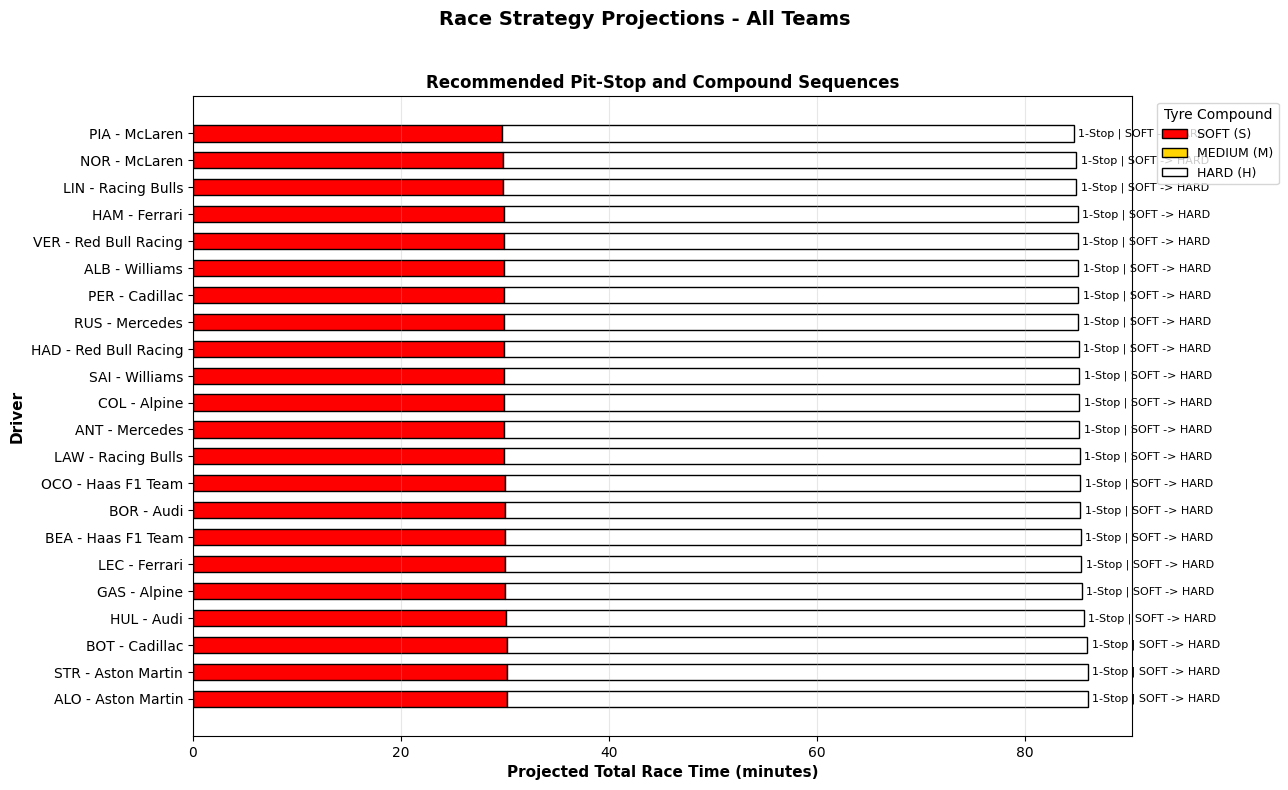

Race strategy using: XGBoost (Tyre Degradation) (R2 = 0.926)
Strategies generated: 17 (5 one-stop, 12 two-stop)
Suggested Race Strategies per Driver
           Team Driver   Type    Compounds         Stint1         Stint2 Stint3  Pit1_Lap Pit2_Lap TotalRaceTime
         Alpine    COL 1-Stop SOFT -> HARD SOFT (25 laps) HARD (46 laps)      -        25     None    1:25:37.55
         Alpine    GAS 1-Stop SOFT -> HARD SOFT (25 laps) HARD (46 laps)      -        25     None    1:25:52.39
   Aston Martin    ALO 1-Stop SOFT -> HARD SOFT (25 laps) HARD (46 laps)      -        25     None    1:26:25.69
   Aston Martin    STR 1-Stop SOFT -> HARD SOFT (25 laps) HARD (46 laps)      -        25     None    1:26:25.60
           Audi    BOR 1-Stop SOFT -> HARD SOFT (25 laps) HARD (46 laps)      -        25     None    1:25:42.61
           Audi    HUL 1-Stop SOFT -> HARD SOFT (25 laps) HARD (46 laps)      -        25     None    1:26:03.32
       Cadillac    BOT 1-Stop SOFT -> HARD SOFT (25 laps) HA

In [32]:
# F1 standard compound display colours and abbreviations
compound_abbr = {'SOFT': 'S', 'MEDIUM': 'M', 'HARD': 'H'}
compound_code_map = {'HARD': 0, 'MEDIUM': 1, 'SOFT': 2}
session_order_map = {'FP1': 1, 'FP2': 2, 'FP3': 3, 'Q': 4, 'R': 5}

# Stint-length constraints (laps)
MAX_STINT_LAPS = {'SOFT': 25, 'MEDIUM': 40, 'HARD': 50}
MIN_STINT_LAPS = {'SOFT': 15, 'MEDIUM': 30, 'HARD': 40}

# Select best tyre degradation model by validation R2
if t_rf_r2 >= t_gb_r2 and t_rf_r2 >= t_xgb_r2:
    degrad_model = t_rf_model
    degrad_model_name = 'Random Forest (Tyre Degradation)'
elif t_gb_r2 >= t_rf_r2 and t_gb_r2 >= t_xgb_r2:
    degrad_model = t_gb_model
    degrad_model_name = 'Gradient Boosting (Tyre Degradation)'
else:
    degrad_model = t_xgb_model
    degrad_model_name = 'XGBoost (Tyre Degradation)'

# Build driver profiles for personalised predictions
driver_profile_ml = (practice_df[practice_df['Session'].isin(['FP1', 'FP2', 'FP3']) & practice_df['LapTime'].notna() & (practice_df['TyreLife'] > WARM_UP_LAPS)]
                     .groupby('Driver', as_index=False).agg({
                         'Team': lambda x: x.mode().iloc[0],
                         'LapNumber': lambda x: x.median(),
                         'Stint': lambda x: x.median(),
                         'SpeedST': lambda x: x.median(),
                         'TrackStatus': lambda x: x.mode().iloc[0],
                         'FreshTyre': lambda x: 'False'
                         }))

driver_profile_ml = driver_profile_ml.copy().reset_index(drop=True)
driver_context = driver_profile_ml.set_index('Driver').to_dict(orient='index')

def lookup_pair(series_a, series_b, lookup_series):
    return pd.Series([lookup_series.get((a, b), np.nan) for a, b in zip(series_a, series_b)], index=series_a.index)

# Function to build one input row for the model based on driver context and tyre life
def build_stint_input_row(driver: str, compound: str, tyre_life: int) -> dict:
    ctx = driver_context.get(driver, {})
    lap_number = ctx.get('LapNumber', 0)
    stint_number = ctx.get('Stint', 0)
    speed_st = ctx.get('SpeedST', 0.0)
    track_status = ctx.get('TrackStatus', 1)
    team = ctx.get('Team', 'Unknown')

    tyre_life_value = int(tyre_life)
    stint_value = int(round(float(stint_number))) if pd.notna(stint_number) else 0
    lap_number_value = int(round(float(lap_number))) if pd.notna(lap_number) else 0
    session_order = session_order_map.get('R', 5)

    return {
        'LapNumber': lap_number_value,
        'TyreLife': tyre_life_value,
        'Stint': stint_value,
        'SpeedST': float(speed_st) if pd.notna(speed_st) else 0.0,
        'TrackStatus': track_status,
        'Compound': compound,
        'Driver': driver,
        'Team': team,
        'Session': 'R',
        'SessionOrder': session_order,
        'FreshTyre': 'False'
    }

# Precompute cumulative stint time lookup to avoid repeated model.predict calls in sorting loops.
def build_driver_stint_cache(driver: str) -> dict:
    rows = [build_stint_input_row(driver, compound, tyre_life)
            for compound in COMPOUNDS
            for tyre_life in range(1, RACE_LAPS + 1)
            ]
    
    input_df = pd.DataFrame(rows)

    global_median = float(practice_df['LapTime'].median())
    driver_median = practice_df.groupby('Driver')['LapTime'].median()
    team_median = practice_df.groupby('Team')['LapTime'].median()
    compound_median = practice_df.groupby('Compound')['LapTime'].median()
    driver_compound_median = practice_df.groupby(['Driver', 'Compound'])['LapTime'].median()
    team_compound_median = practice_df.groupby(['Team', 'Compound'])['LapTime'].median()

    input_df['DriverMedianLapTime'] = input_df['Driver'].map(driver_median).fillna(global_median)
    input_df['TeamMedianLapTime'] = input_df['Team'].map(team_median).fillna(global_median)
    input_df['CompoundMedianLapTime'] = input_df['Compound'].map(compound_median).fillna(global_median)
    input_df['DriverCompoundMedianLapTime'] = lookup_pair(input_df['Driver'],
                                                          input_df['Compound'],
                                                          driver_compound_median
            ).fillna(input_df['DriverMedianLapTime']).fillna(input_df['CompoundMedianLapTime']).fillna(global_median)
    input_df['TeamCompoundMedianLapTime'] = lookup_pair(input_df['Team'],
                                                        input_df['Compound'],
                                                        team_compound_median
            ).fillna(input_df['TeamMedianLapTime']).fillna(input_df['CompoundMedianLapTime']).fillna(global_median)

    # Match prediction input to the trained tyre-degradation feature schema.
    required_degrad_features = list(t_features)
    for col in required_degrad_features:
        if col in input_df.columns:
            continue

        if col in practice_df.columns and pd.api.types.is_numeric_dtype(practice_df[col]):
            series = pd.to_numeric(practice_df[col], errors='coerce')
            input_df[col] = float(series.median()) if series.notna().any() else 0.0
        elif col in practice_df.columns:
            mode_vals = practice_df[col].dropna().mode()
            input_df[col] = mode_vals.iloc[0] if len(mode_vals) > 0 else 'Unknown'
        elif col in ['Compound', 'Driver', 'Team', 'Session', 'FreshTyre']:
            defaults = {'Compound': 'SOFT',
                        'Driver': driver,
                        'Team': driver_context.get(driver, {}).get('Team', 'Unknown'),
                        'Session': 'R',
                        'FreshTyre': 'False'}
            input_df[col] = defaults[col]
        else:
            input_df[col] = 0.0

    input_df = input_df.reindex(columns=required_degrad_features)

    predicted = degrad_model.predict(input_df)

    input_df['PredLapTime'] = predicted
    input_df['ComStintTime'] = input_df.groupby('Compound')['PredLapTime'].cumsum()

    cache = {}
    for compound in COMPOUNDS:
        compound_cum = input_df.loc[input_df['Compound'] == compound, 'ComStintTime'].to_numpy()
        for laps in range(1, RACE_LAPS + 1):
            cache[(compound, laps)] = float(compound_cum[laps - 1])

    return cache

# Enforce strategy validity: at least two compounds plus compound-specific min/max stint limits.
def strategy_is_valid(stints_raw):
    compounds_used = {compound for compound, _ in stints_raw}
    if len(compounds_used) < 2:
        return False

    for compound, laps in stints_raw:
        if laps < MIN_STINT_LAPS.get(compound, 1):
            return False
        if laps > MAX_STINT_LAPS.get(compound, RACE_LAPS):
            return False

    return True

# Pit window sweep ranges
ONE_STOP = list(range(15, 44, 2))
TWO_W1 = list(range(12, 25, 3))
TWO_W2 = list(range(28, 47, 3))

# Build strategy universe (times are computed per driver below)
strategies = []
strategy_id = 0

for c1, c2 in product(COMPOUNDS, COMPOUNDS):
    if c1 == c2:
        continue
    for w in ONE_STOP:
        s1, s2 = w, RACE_LAPS - w
        if s1 < 5 or s2 < 5:
            continue
        stints_raw = [(c1, s1), (c2, s2)]
        if not strategy_is_valid(stints_raw):
            continue
        strategies.append({'StrategyId': strategy_id,
                           'Type': '1-Stop',
                           'Compounds': f"{c1} -> {c2}",
                           'Stint1': f"{c1} ({s1} laps)",
                           'Stint2': f"{c2} ({s2} laps)",
                           'Stint3': '-',
                           'Pit1_Lap': w,
                           'Pit2_Lap': None,
                           'TotalTime': 0.0,
                           'Stints_raw': stints_raw
                           })
        strategy_id += 1

for c1, c2, c3 in product(COMPOUNDS, COMPOUNDS, COMPOUNDS):
    if len({c1, c2, c3}) < 2:
        continue
    for w1, w2 in product(TWO_W1, TWO_W2):
        if w2 <= w1 + 8:
            continue
        s1, s2, s3 = w1, w2 - w1, RACE_LAPS - w2
        if s1 < 5 or s2 < 5 or s3 < 5:
            continue
        stints_raw = [(c1, s1), (c2, s2), (c3, s3)]
        if not strategy_is_valid(stints_raw):
            continue
        strategies.append({'StrategyId': strategy_id,
                           'Type': '2-Stop',
                           'Compounds': f"{c1} -> {c2} -> {c3}",
                           'Stint1': f"{c1} ({s1} laps)",
                           'Stint2': f"{c2} ({s2} laps)",
                           'Stint3': f"{c3} ({s3} laps)",
                           'Pit1_Lap': w1,
                           'Pit2_Lap': w2,
                           'TotalTime': 0.0,
                           'Stints_raw': stints_raw
                           })
        strategy_id += 1

def fmt_race_time(s: float) -> str:
    h = int(s // 3600)
    m = int((s % 3600) // 60)
    return f"{h}:{m:02d}:{s % 60:05.2f}"

recommendations = []
for driver in driver_profile_ml['Driver']:
    stint_cache = build_driver_stint_cache(driver)

    scored_rows = []
    for strategy in strategies:
        stint_total = sum(stint_cache[(compound, laps)] for compound, laps in strategy['Stints_raw'])
        pit_loss = (len(strategy['Stints_raw']) - 1) * PIT_STOP_LOSS
        total_time = stint_total + pit_loss

        scored_rows.append({'StrategyId': strategy['StrategyId'],
                            'TotalTime': total_time
                            })

    scored_df = pd.DataFrame(scored_rows).sort_values('TotalTime').reset_index(drop=True)
    primary_id = int(scored_df.loc[0, 'StrategyId'])
    primary_time = float(scored_df.loc[0, 'TotalTime'])

    primary_strategy = next(s for s in strategies if s['StrategyId'] == primary_id)

    strategy = {k: v for k, v in primary_strategy.items() if k not in ['Stints_raw', 'StrategyId']}
    strategy.update({'Driver': driver,
                     'Team': driver_context[driver]['Team'],
                     'TotalTime': primary_time,
                     # Store per-stint compounds and times (seconds) for plotting coloured segments
                     'StintCompounds': [c for c, _ in primary_strategy['Stints_raw']],
                     'StintLaps': [laps for _, laps in primary_strategy['Stints_raw']],
                     'StintTimesSec': [stint_cache[(c, laps)] for c, laps in primary_strategy['Stints_raw']]
                     })
    recommendations.append(strategy)

rec_df = pd.DataFrame(recommendations)
rec_df['TotalRaceTime'] = rec_df['TotalTime'].apply(fmt_race_time)
race_strategy_plot_df = rec_df.copy().sort_values('TotalTime').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(13, max(6, 0.35 * len(race_strategy_plot_df))))
driver_labels = race_strategy_plot_df['Driver'] + ' - ' + race_strategy_plot_df['Team']

# Convert total time to minutes for axis scaling
race_strategy_plot_df['TotalTimeMin'] = race_strategy_plot_df['TotalTime'] / 60.0

# Plot stacked horizontal bars with tyre-colour per stint
y_positions = np.arange(len(race_strategy_plot_df))
for i, row in race_strategy_plot_df.iterrows():
    left = 0.0
    for comp, tsec in zip(row['StintCompounds'], row['StintTimesSec']):
        tmin = tsec / 60.0
        ax.barh(y_positions[i], tmin, left=left, color=tyre_palette.get(comp, '#CCCCCC'), edgecolor='black', height=0.6)
        left += tmin

ax.set_yticks(y_positions)
ax.set_yticklabels(driver_labels)
ax.invert_yaxis()
ax.set_xlabel('Projected Total Race Time (minutes)', fontsize=11, fontweight='bold')
ax.set_ylabel('Driver', fontsize=11, fontweight='bold')
ax.set_title('Recommended Pit-Stop and Compound Sequences', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Annotate strategy type and compound sequence at end of bars
for i, row in race_strategy_plot_df.iterrows():
    ax.text(row['TotalTimeMin'] + 0.08, i, f"{row['Type']} | {row['Compounds']}", va='center', fontsize=8)

# Create a legend for compound colours
legend_patches = [Patch(facecolor=tyre_palette.get(c, '#CCCCCC'), edgecolor='black', label=f"{c} ({compound_abbr.get(c, c)})") for c in COMPOUNDS]
ax.legend(handles=legend_patches, title='Tyre Compound', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.suptitle('Race Strategy Projections - All Teams', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
save_figure(fig, f"f1_{year}_{cache_gp}_race_strategy.png")

print(f"Race strategy using: {degrad_model_name} (R2 = {max(t_rf_r2, t_gb_r2, t_xgb_r2):.3f})")
print(f"Strategies generated: {len(strategies)} "
      f"({sum(1 for s in strategies if s['Type']=='1-Stop')} one-stop, "
      f"{sum(1 for s in strategies if s['Type']=='2-Stop')} two-stop)"
      )
print("Suggested Race Strategies per Driver")
print(rec_df[['Team', 'Driver', 'Type', 'Compounds', 'Stint1',
              'Stint2', 'Stint3', 'Pit1_Lap', 'Pit2_Lap', 'TotalRaceTime']].sort_values(['Team', 'Driver'])
              .to_string(index=False))

 ## Conclusion

 This notebook delivers an end-to-end workflow for Austrian GP qualifying pace analysis using FP1-FP3 data. It covers data extraction, cleaning, all-team filtering, exploratory diagnostics, model benchmarking, and driver-level tyre-life scenario projections.

 The analysis shows that lap time is shaped by multiple interacting factors rather than any single dominant variable. Tyre condition, session context, stint progression, and straight-line speed all matter, but their combined effect is more informative than their individual averages or simple correlations.

 The model results support the use of ensemble regressors for this problem, especially when the objective is relative pace comparison and scenario exploration. Absolute qualifying prediction remains harder and would benefit from calibration or direct qualifying-session training data.

 ### Key Findings

 1. Practice pace varies not just by team but by session structure, stint pattern, and lap context, which makes raw averages incomplete on their own.
 2. Tyre compound and tyre life both influence lap time, but the effect is noisy enough that context-aware modeling is necessary.
 3. Ensemble models outperform the naive baseline, which confirms that the feature set captures usable predictive signal.
 4. The qualifying projection is most valuable as a controlled scenario tool for comparing drivers and teams under shared assumptions.

 ### Recommendations

 #### For Performance Engineering

 1. Apply a post-model calibration step before using practice-trained outputs as absolute qualifying estimates.
 2. Treat relative team and driver deltas as the most reliable operational signal when absolute offset remains unstable.
 3. Use tyre-life sensitivity results together with run-plan context rather than in isolation.

 #### For Data Science

 1. Separate qualifying-oriented laps from general practice laps more aggressively to reduce systematic bias.
 2. Add richer inputs such as sector splits, mini-sector traces, traffic indicators, and weather or track evolution variables.
 3. Compare model quality not only on point accuracy but also on calibration and stability across sessions.

 #### For Strategy and Simulation

 1. Use the projection outputs as scenario guidance, not as deterministic single-lap truth.
 2. Pair pace estimates with uncertainty ranges when comparing setup or tyre-age alternatives.
 3. Revisit the comparison after each session update so decisions reflect the latest state of the weekend.

 #### Next Analysis Steps

 1. Evaluate additional algorithms or tuned variants, including a fuller XGBoost diagnostic pass and calibrated ensemble comparisons.
 2. Add uncertainty-aware outputs such as prediction intervals or quantile models for decision support.
 3. Test both shared and driver-specific models to measure where specialization improves forecast quality.